In [508]:
pip uninstall numpy tensorflow keras -y


Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4
Found existing installation: tensorflow 2.15.0
Uninstalling tensorflow-2.15.0:
  Successfully uninstalled tensorflow-2.15.0
Found existing installation: keras 2.15.0
Uninstalling keras-2.15.0:
  Successfully uninstalled keras-2.15.0
Note: you may need to restart the kernel to use updated packages.


In [509]:

pip install numpy==1.26.4


  Using cached numpy-1.26.4-cp311-cp311-win_amd64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp311-cp311-win_amd64.whl (15.8 MB)
Note: you may need to restart the kernel to use updated packages.


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-intel 2.15.0 requires keras<2.16,>=2.15.0, which is not installed.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
sklearn-genetic-opt 0.12.0 requires scikit-learn>=1.5.0, but you have scikit-learn 1.4.2 which is incompatible.

[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [510]:

pip install tensorflow==2.15.0

  Using cached tensorflow-2.15.0-cp311-cp311-win_amd64.whl.metadata (3.6 kB)
  Using cached keras-2.15.0-py3-none-any.whl.metadata (2.4 kB)
Using cached tensorflow-2.15.0-cp311-cp311-win_amd64.whl (2.1 kB)
Using cached keras-2.15.0-py3-none-any.whl (1.7 MB)

   ---------------------------------------- 0/2 [keras]
   ---------------------------------------- 0/2 [keras]
   ---------------------------------------- 0/2 [keras]
   ---------------------------------------- 0/2 [keras]
   ---------------------------------------- 0/2 [keras]
   ---------------------------------------- 0/2 [keras]
   ---------------------------------------- 0/2 [keras]
   ---------------------------------------- 0/2 [keras]
   ---------------------------------------- 0/2 [keras]
   ---------------------------------------- 0/2 [keras]
   ---------------------------------------- 0/2 [keras]
   ---------------------------------------- 0/2 [keras]
   ---------------------------------------- 0/2 [keras]
   ----------


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [602]:
import pandas as pd
import numpy as np
from fredapi import Fred
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.outliers_influence import variance_inflation_factor
import scipy.stats as stats
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [603]:
# Insert your FRED API key
fred = Fred(api_key='7c555b88e31520b011cc33e23aba5fb8')

# Define date range
start_date = '2009-11-01'
end_date = '2024-12-31'

# Target variable: WTI crude oil price
wti = fred.get_series('DCOILWTICO', start_date, end_date)

In [604]:

# Gold futures (COMEX)
gold = yf.download("GC=F", start=start_date, end=end_date)

# Use adjusted close (or Close)
gold_series = gold["Close"]["GC=F"]

[*********************100%***********************]  1 of 1 completed


In [605]:
ovx = yf.download("^OVX", start="2009-11-01", end="2024-12-31")
oil_volatility = ovx['Close']['^OVX']

[*********************100%***********************]  1 of 1 completed


In [606]:
# Interest Rates
y3 = fred.get_series('DGS3', start_date, end_date)   # 3-Year Treasury
y10 = fred.get_series('DGS10', start_date, end_date) # 10-Year Treasury

# Yield Spread (10Y - 3Y)
yield_spread = y10 - y3

# Industrial Production
indpro = fred.get_series('INDPRO', "2009-11-01", end_date)

In [607]:
# S&P 500 index
#sp500 = fred.get_series('SP500', start_date, end_date)

# VIX volatility index
vix = fred.get_series('VIXCLS', start_date, end_date)

# USD index (Trade Weighted Dollar Index)
usd = fred.get_series('DTWEXBGS', start_date, end_date)



In [608]:
sp500 = yf.download("^GSPC", start=start_date, end=end_date)
sp500=sp500["Close"]['^GSPC']


[*********************100%***********************]  1 of 1 completed


In [609]:
# Brent crude oil price from FRED
brent = fred.get_series('DCOILBRENTEU', start_date, end_date)
brent.name = 'Brent'

In [610]:
for df in [wti, sp500, vix, usd, gold_series, yield_spread, oil_volatility, brent]:
    df.index = pd.to_datetime(df.index)
    df.sort_index(inplace=True)

In [611]:
data = pd.concat(
    [wti, sp500, vix, usd, gold_series, yield_spread, oil_volatility, brent],
    axis=1,
    join='outer'
)

In [612]:
data.columns = ['WTI', 'SP500', 'VIX', 'USD', "Gold", "Yield", "Oil_Volatility", "brent"]
data

,WTI,SP500,VIX,USD,Gold,Yield,Oil_Volatility,brent
2009-11-02,78.08,1042.880005,29.78,92.4501,1053.400024,2.01,41.779999,75.56
2009-11-03,79.58,1045.410034,28.81,92.9037,1084.300049,2.04,41.580002,75.68
2009-11-04,80.30,1046.500000,27.72,92.3725,1086.699951,2.11,40.599998,78.21
2009-11-05,79.64,1066.630005,25.43,92.3437,1088.699951,2.13,38.980000,78.02
2009-11-06,77.40,1069.300049,24.19,92.3848,1095.099976,2.14,38.700001,75.51
...,...,...,...,...,...,...,...,...
2024-12-25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-12-26,70.38,6037.589844,14.73,128.3329,2638.800049,0.23,30.010000,NaN
2024-12-27,71.28,5970.839844,15.95,128.4500,2617.199951,0.26,30.209999,73.77
2024-12-30,71.73,5906.939941,17.40,128.8205,2606.100098,0.26,30.770000,74.24


In [613]:
indpro_release = indpro.copy()

# shift to end of month
indpro_release.index = indpro_release.index + pd.offsets.MonthEnd(0)

# add ~15 days release lag (approximation)
indpro_release.index = indpro_release.index + pd.Timedelta(days=15)

data['INDPRO'] = indpro_release.reindex(data.index).ffill()

In [614]:
data.index.name = "Date"
#get data just from 2010
data=data.loc[data.index>"2009-12-31"]

In [615]:
#saving sample dataset
data.to_csv("wti_data.csv", index=True)

In [616]:
#printing datashape
print(data.shape)
#printing information about the data
print(data.info())

(3913, 9)
<class 'pandas.DataFrame'>
DatetimeIndex: 3913 entries, 2010-01-01 to 2024-12-31
Freq: B
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   WTI             3765 non-null   float64
 1   SP500           3773 non-null   float64
 2   VIX             3793 non-null   float64
 3   USD             3732 non-null   float64
 4   Gold            3770 non-null   float64
 5   Yield           3752 non-null   float64
 6   Oil_Volatility  3773 non-null   float64
 7   brent           3795 non-null   float64
 8   INDPRO          3913 non-null   float64
dtypes: float64(9)
memory usage: 305.7 KB
None


In [617]:
#printing missing values 
print(data.isna().sum())

WTI               148
SP500             140
VIX               120
USD               181
Gold              143
Yield             161
Oil_Volatility    140
brent             118
INDPRO              0
dtype: int64


In [618]:
data.describe()

,WTI,SP500,VIX,USD,Gold,Yield,Oil_Volatility,brent,INDPRO
count,3765.000000,3773.000000,3793.000000,3732.000000,3770.000000,3752.000000,3773.000000,3795.000000,3913.000000
mean,72.073995,2727.439112,18.373905,107.910123,1544.688089,0.880989,37.015550,77.990804,99.017619
std,21.475895,1264.115621,6.958175,11.879190,350.965404,0.794384,17.005452,24.756356,3.620591
min,-36.980000,1022.580017,9.140000,85.469200,1050.800049,-0.730000,14.500000,9.120000,84.561900
25%,53.290000,1701.839966,13.600000,93.915325,1260.699951,0.210000,28.580000,58.910000,97.871300
50%,73.140000,2431.770020,16.590000,112.097750,1435.800049,0.850000,34.049999,76.430000,100.082000
75%,89.560000,3818.800049,21.160000,116.730975,1784.700012,1.520000,42.060001,101.145000,101.253000
max,123.640000,6090.270020,82.690000,129.277500,2788.500000,2.450000,325.149994,133.180000,104.100400


The number of observations in the raw dataset was about 3700-3900 for each variable which is indicative that there is good to very good coverage from 2010 until 2024. There are large variations in crude oil price (the variance is around 462) as well as in all the other financial and volatility metrics; for example VIX and Oil_Volatility have extremely high/low values at times of major market disruption. In contrast industrial production has relatively little variation compared to crude oil prices as it reflects an overall trend of a longer-term nature than most macro-economic factors. These summary statistics demonstrate the highly irregular or "volatile" nature of many of the data elements in this database; therefore, they provide motivation for transforming the data into forms that may be more suitable for future analysis.

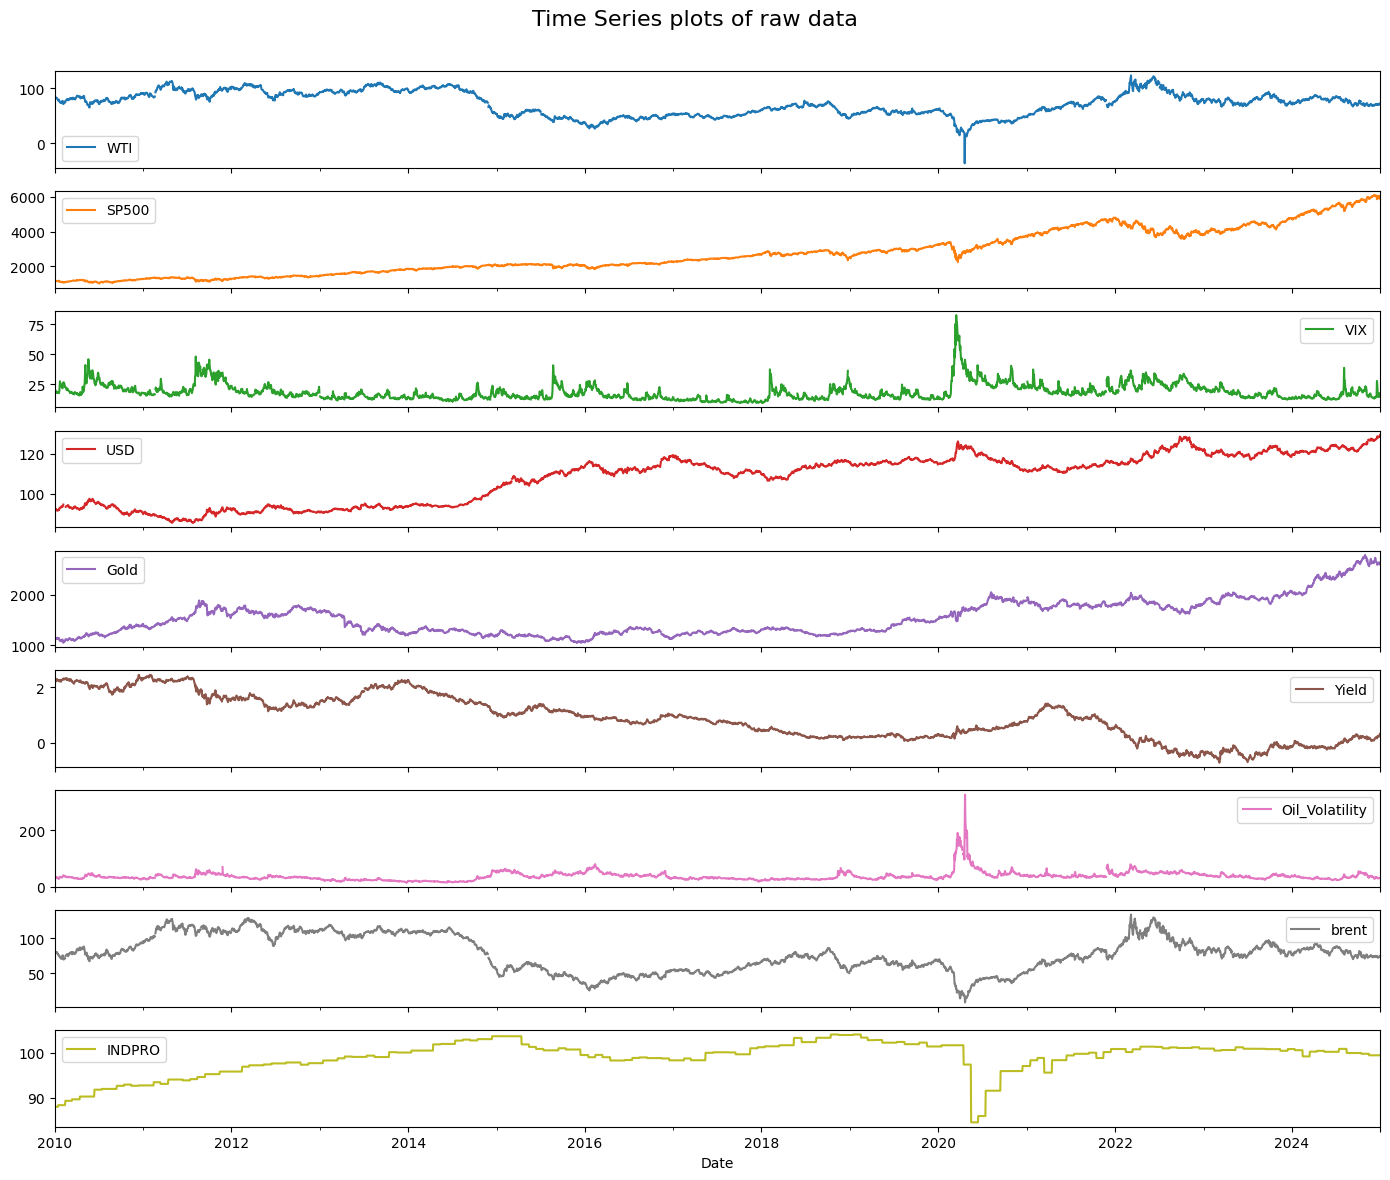

In [619]:
axes = data.plot(subplots=True, figsize=(14, 12))

fig = axes[0].get_figure()
fig.suptitle("Time Series plots of raw data", fontsize=16)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

The Raw Variables have obvious Trends, Structural Breaks & High Volatility Periods. There was a notable Disruption in the 2020 COVID-19 Crisis Where All Four Variables (WTI Price, VIX, OVX & Industrial Production) Experienced A Significant Shock. It's Obvious That all four variables are Non-Stationary and Will Need to be Transformed Before Modeling.

## Market & Macro Indicators Overview (2010–2024)

This figure compares several major financial and economic indicators over time and highlights how markets react to economic uncertainty and global events.

- **WTI Oil Prices:** Oil prices fluctuate significantly due to supply-demand shocks, geopolitical tensions, and global crises. The sharp collapse in 2020 reflects the COVID-19 demand shock.

- **S&P 500:** The stock market shows a strong long-term upward trend despite temporary declines during periods of uncertainty, especially in 2020.

- **VIX (Volatility Index):** The VIX measures market fear and uncertainty. Large spikes, particularly in 2020, indicate periods of high financial stress.

- **USD Index:** The U.S. dollar generally strengthened over time, especially during crises when investors moved toward safe-haven assets.

- **Gold Prices:** Gold trends upward over the long run as investors seek protection against inflation and economic instability.

- **Treasury Yield:** Bond yields generally declined over the decade, reflecting lower interest rates and slower economic growth expectations.

- **Oil Volatility:** Oil market volatility spikes during major disruptions, with the largest surge occurring during the COVID-19 pandemic.

- **Industrial Production (INDPRO):** Industrial production grew gradually before experiencing a sharp decline in 2020 due to economic shutdowns, followed by recovery afterward.

Overall, the chart illustrates the interconnected relationship between financial markets, commodities, investor sentiment, and macroeconomic activity.

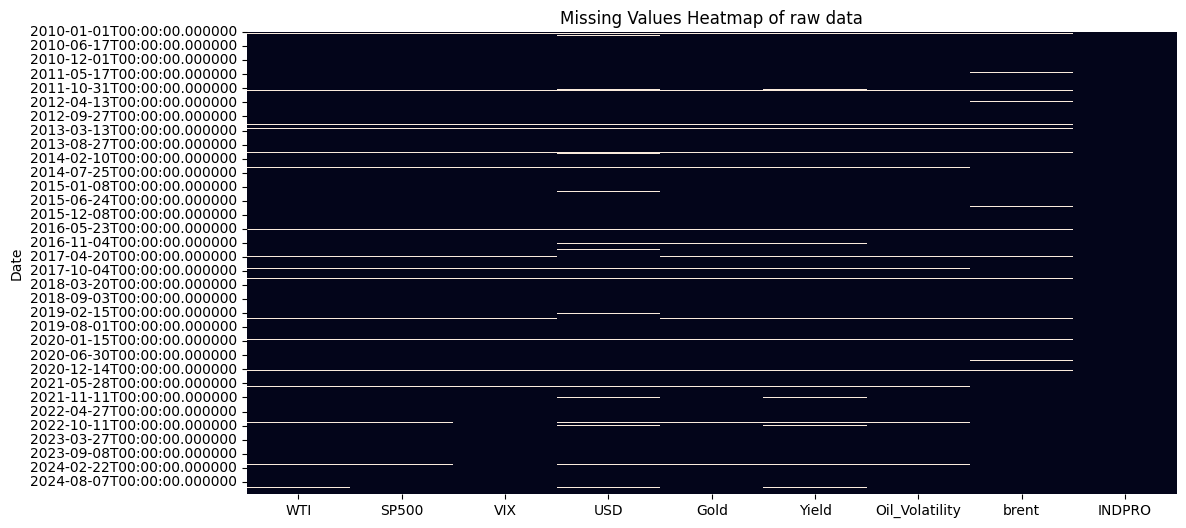

In [620]:
plt.figure(figsize=(12,6))
sns.heatmap(data.isna(), cbar=False)
plt.title("Missing Values Heatmap of raw data")
plt.show()

Missing values are limited and primarily occur on market holidays and non-trading days. The overall dataset is largely complete, indicating that only minor preprocessing and imputation are required before analysis.

In [621]:
#check for duplicates 
print(data.index.duplicated().sum())

0


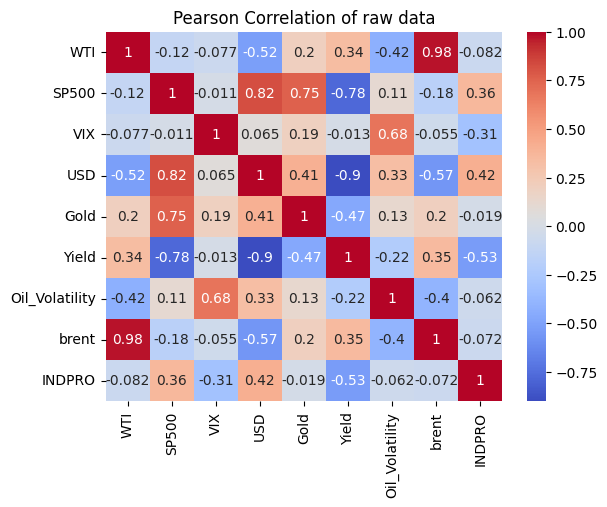

In [622]:
corr = data.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Pearson Correlation of raw data")
plt.show()

The correlation matrix reveals several economically meaningful relationships. Equity and oil market variables show positive associations, while volatility indicators generally exhibit negative relationships with market performance. However, correlations alone do not capture potential nonlinear dependencies.

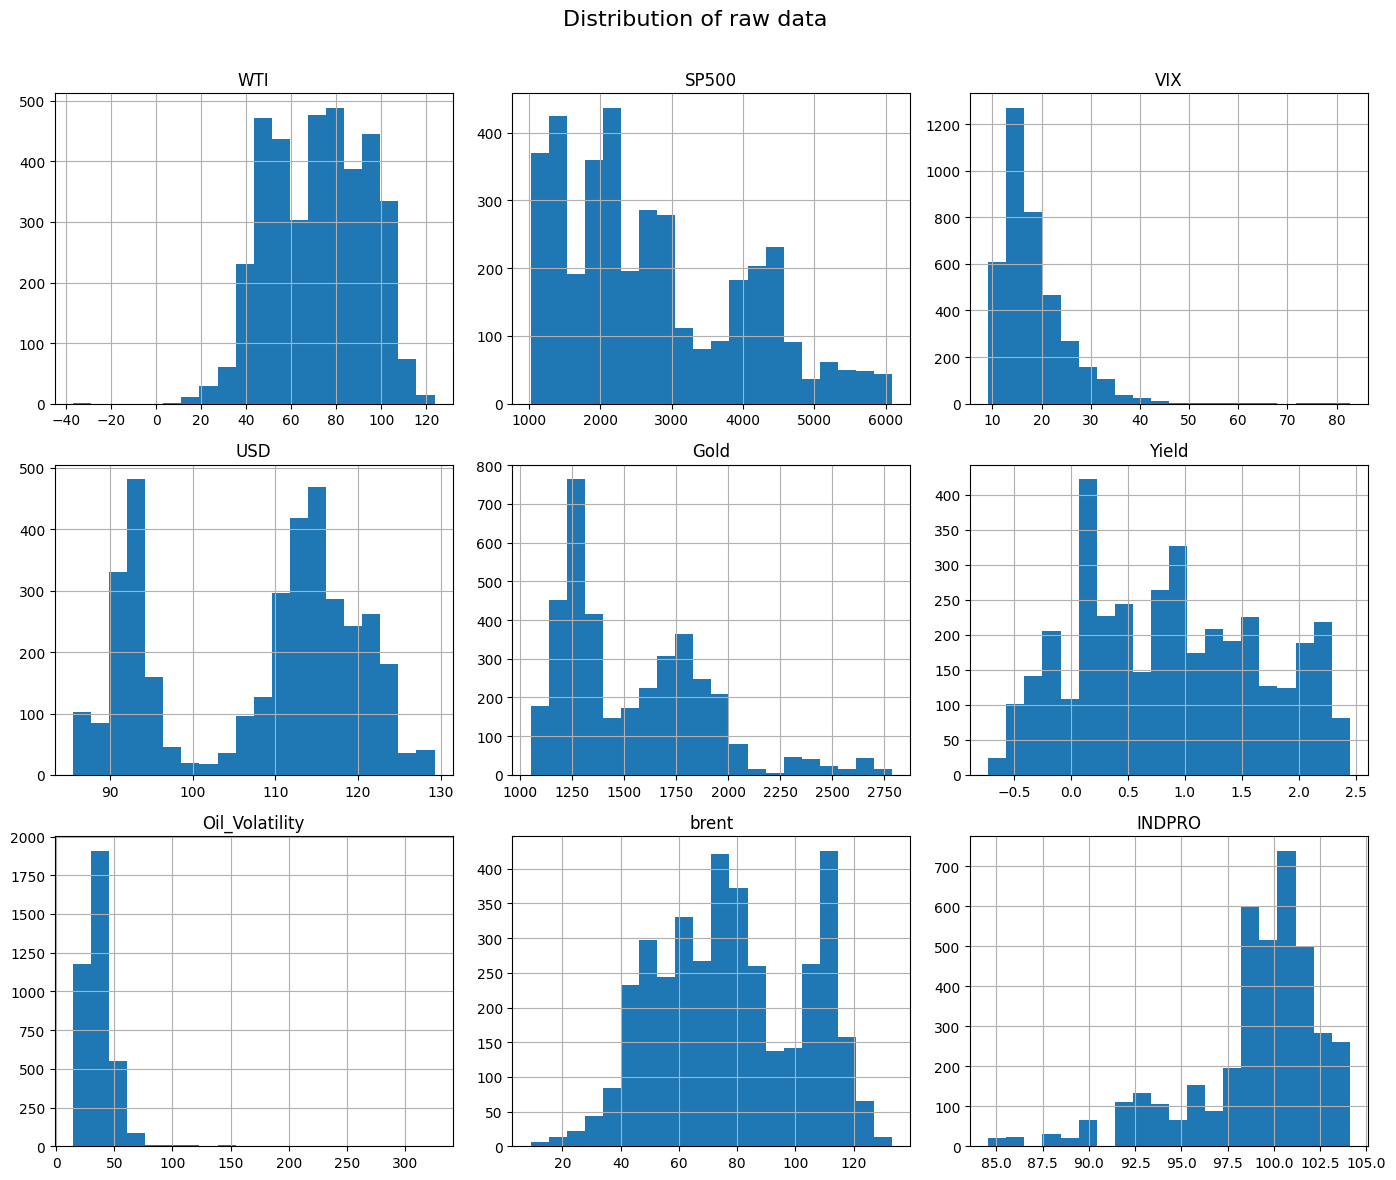

In [623]:
data.hist(figsize=(14, 12), bins=20)

plt.suptitle("Distribution of raw data", fontsize=16)

plt.tight_layout(rect=[0, 0, 1, 0.97])  
plt.show()

MOST RAW VARIABLES HAVE Distributions that are SKewed AND Not Normal. VIX and OVX have long right tail distributions due to times of crisis and also large value range in time for many types of financial assets like gold, wti, s&p 500; therefore this is an additional reason to transform your data.

In [624]:
# Replace inf values first
data = data.replace([np.inf, -np.inf], np.nan)

# Remove invalid non-positive values
data.loc[data['WTI'] == 0, 'WTI'] = np.nan
data.loc[data['SP500'] <= 0, 'SP500'] = np.nan
data.loc[data['USD'] <= 0, 'USD'] = np.nan
data.loc[data['Gold'] <= 0, 'Gold'] = np.nan
data.loc[data['VIX'] < 0, 'VIX'] = np.nan
data.loc[data['Oil_Volatility'] < 0, 'Oil_Volatility'] = np.nan

In [625]:
results = []
temp=data

for col in temp.columns:
    result = adfuller(temp[col].dropna())
    
    results.append({
        'Variable': col,
        'ADF Statistic': round(result[0], 4),
        'p-value': round(result[1], 4),
        'Conclusion': 'Stationary' if result[1] < 0.05 else 'Non-stationary'
    })

# Convert to DataFrame
adf_table = pd.DataFrame(results)
adf_table = adf_table.sort_values(by='p-value')
# Display nicely
adf_table

,Variable,ADF Statistic,p-value,Conclusion
2,VIX,-5.2520,0.0000,Stationary
6,Oil_Volatility,-6.4773,0.0000,Stationary
8,INDPRO,-3.6066,0.0056,Stationary
0,WTI,-2.3670,0.1513,Non-stationary
7,brent,-2.1036,0.2431,Non-stationary
5,Yield,-1.6636,0.4500,Non-stationary
3,USD,-0.5572,0.8804,Non-stationary
4,Gold,0.0383,0.9616,Non-stationary
1,SP500,1.4265,0.9972,Non-stationary


Based on the ADF test, most of the columns are non-stationary. The only stationary columns are VIX, oil volatility and industrial production. VIX and OVX are natural fluctuations of their own averages and therefore will most likely remain stationary as they do not exhibit long-term uptrends or downtrends. INDPRO has appeared stationary in your time period from 2010–2024; INDPRO’s growth rate was at an almost steady state throughout this time frame with large disruptions caused by Covid-19, thus pushing INDPRO back towards its historical mean, instead of continuing along a well-defined trend.

In [626]:
# Sort data
data = data.sort_index()

#  Remove duplicates
data = data[~data.index.duplicated(keep='first')]

# Convert to numeric
data = data.apply(pd.to_numeric, errors='coerce')

# Convert to weekly frequency
data_weekly = data.resample('W-FRI').last()

# Handle missing values
# Forward-fill small gaps
data_weekly = data_weekly.ffill(limit=2)

# Remove remaining missing rows
data_weekly = data_weekly.dropna()

# LOG RETURNS
returns = pd.DataFrame()
returns['WTI'] = np.log(data_weekly['WTI'] / data_weekly['WTI'].shift(1))
returns['SP500'] = np.log(data_weekly['SP500'] / data_weekly['SP500'].shift(1))
returns['USD'] = np.log(data_weekly['USD'] / data_weekly['USD'].shift(1))
returns['Gold'] = np.log(data_weekly['Gold'] / data_weekly['Gold'].shift(1))
returns['Brent'] = np.log(data_weekly['brent'] / data_weekly['brent'].shift(1))

# DIFFERENCES
returns['VIX_diff'] = data_weekly['VIX'].diff()
returns['OVX_diff'] = data_weekly['Oil_Volatility'].diff()
returns['Yield_diff'] = data_weekly['Yield'].diff()

# PERCENTAGE CHANGE
returns['INDPRO_pct'] = data_weekly['INDPRO'].pct_change()

# LAGGED FEATURES
returns['WTI_lag1'] = returns['WTI'].shift(1)
returns['WTI_lag2'] = returns['WTI'].shift(2)

# TARGET VARIABLE
returns['Target'] = returns['WTI'].shift(-1)

# FINAL DATASET
model_data = returns.dropna()

In [627]:
model_data.head()

,WTI,SP500,USD,Gold,Brent,VIX_diff,OVX_diff,Yield_diff,INDPRO_pct,WTI_lag1,WTI_lag2,Target
Date,,,,,,,,,,,,
2010-01-29,-0.019035,-0.016522,0.008792,-0.005708,-0.021261,-2.69,-0.799999,2.000000e-02,0.0000,-0.048758,-0.059507,-0.023612
2010-02-05,-0.023612,-0.007177,0.009109,-0.028852,-0.015427,1.49,5.940002,6.000000e-02,0.0000,-0.019035,-0.048758,0.040760
2010-02-12,0.040760,0.008703,-0.006619,0.034836,0.019492,-3.38,-3.950001,4.440892e-16,0.0000,-0.023612,-0.019035,0.073597
2010-02-19,0.073597,0.030817,-0.000433,0.028770,0.072688,-2.71,-1.410000,-4.000000e-02,0.0109,0.040760,-0.023612,-0.000627
2010-02-26,-0.000627,-0.004228,-0.003163,-0.002679,-0.006787,-0.52,-1.810001,-2.000000e-02,0.0000,0.073597,0.040760,0.022083


In [628]:
model_data.to_csv("model_data.csv", index=True)

In [629]:
data_weekly.isna().sum()

WTI               0
SP500             0
VIX               0
USD               0
Gold              0
Yield             0
Oil_Volatility    0
brent             0
INDPRO            0
dtype: int64

In [630]:
#checking for extreme values 
z_scores = (model_data - model_data.mean()) / model_data.std()

outliers = np.abs(z_scores) > 4

outlier_counts = outliers.sum()

print(outlier_counts)

WTI           4
SP500         5
USD           2
Gold          3
Brent         6
VIX_diff      5
OVX_diff      8
Yield_diff    2
INDPRO_pct    6
WTI_lag1      4
WTI_lag2      4
Target        4
dtype: int64


there were very few high count values for outliers within this dataset. The largest counts of extreme data points existed in OVX_diff (8), INDPRO_pct (6), SP500 (5), and VIX_diff (5); nearly all remaining series contained between two and four outliers. As you would expect given how low those numbers are, outliers exist at some degree throughout the data set

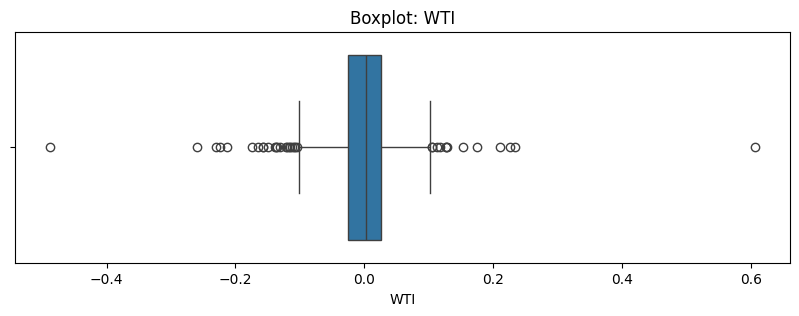

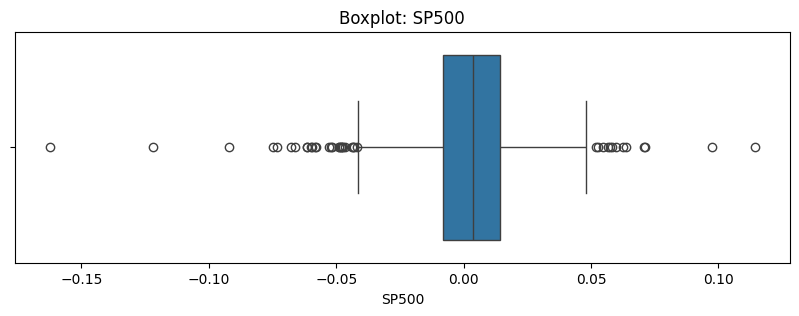

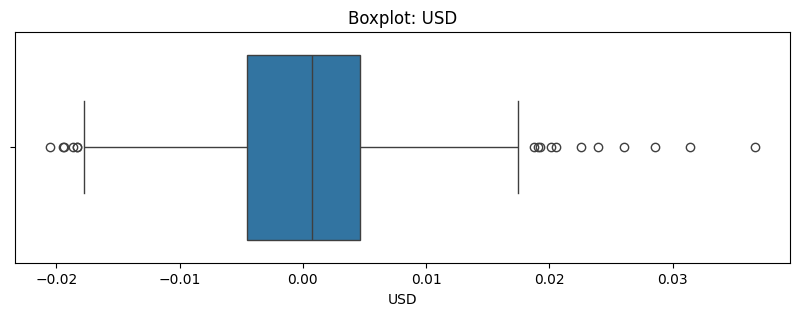

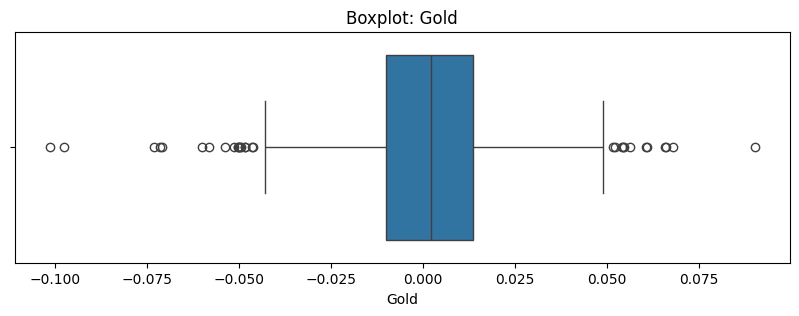

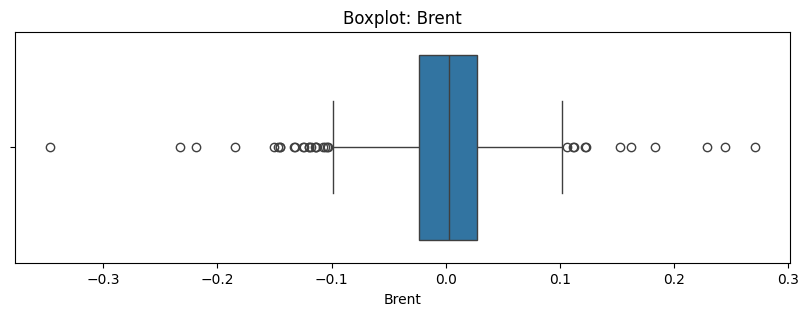

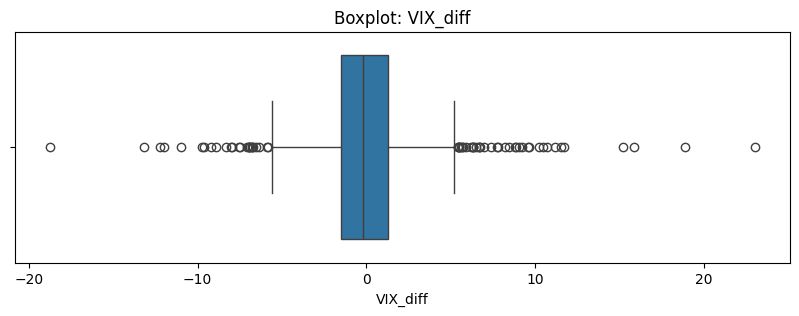

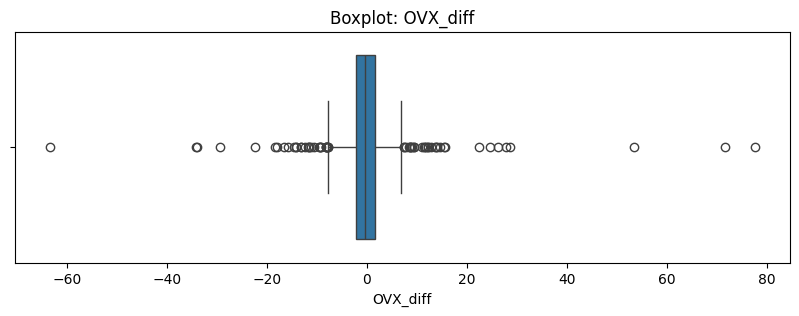

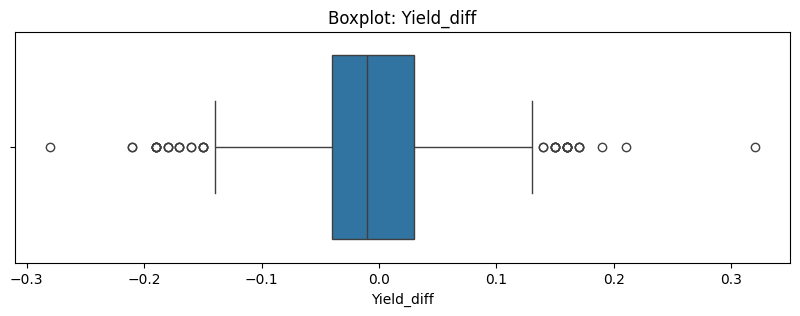

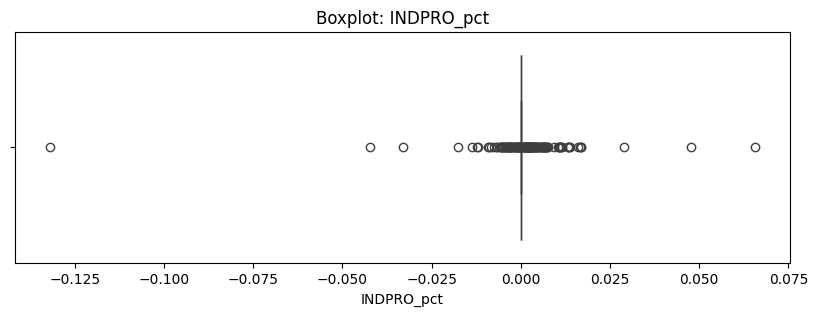

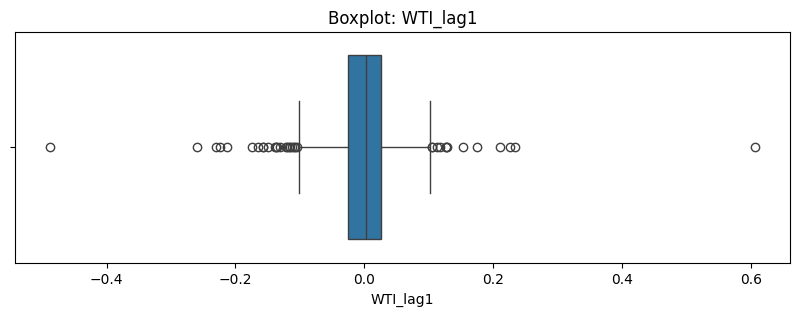

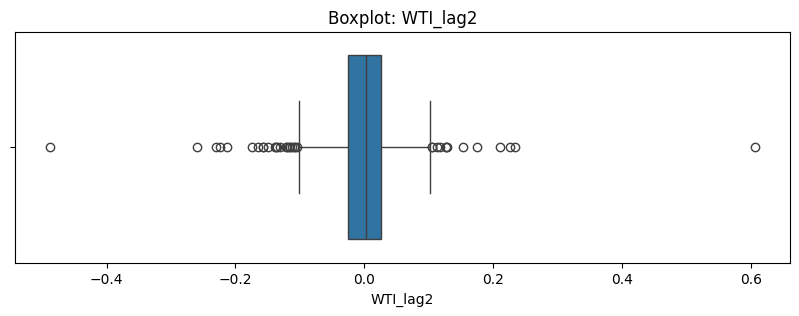

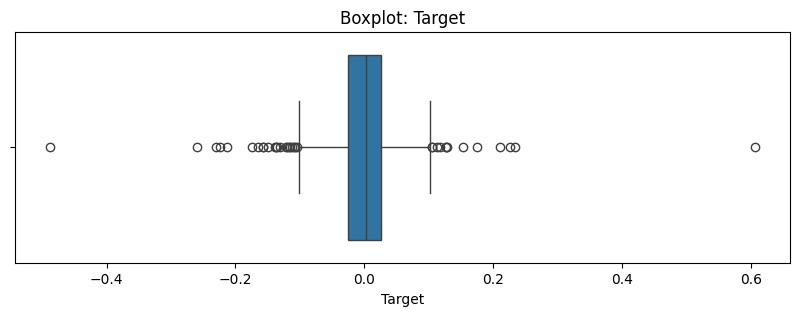

In [631]:
for col in model_data.columns:
    plt.figure(figsize=(10,3))
    
    sns.boxplot(x=model_data[col])
    
    plt.title(f'Boxplot: {col}')
    plt.show()

The Box Plots were created to establish if there existed outliers; and also evaluate the distribution of the transformed data. 
Many of the Data Variables have a mean close to zero, which means that all of the transformations removed any existing long term trend from the Data; and stabilized the Data.

There are many Data Variables with extreme points. Some examples include WTI Returns, VIX Differences, and OVX Differences. 
These extreme Data Points are associated with significant Market Events, (i.e., the COVID-19 Oil Price Shock); and periods of Financial Uncertainty. 
Since these extreme Data Values are realizations of Market Behavior instead of errors in the Data Collection Process, we chose to retain them in our original Data Set so that we could preserve some valuable information for use in Forecasting.

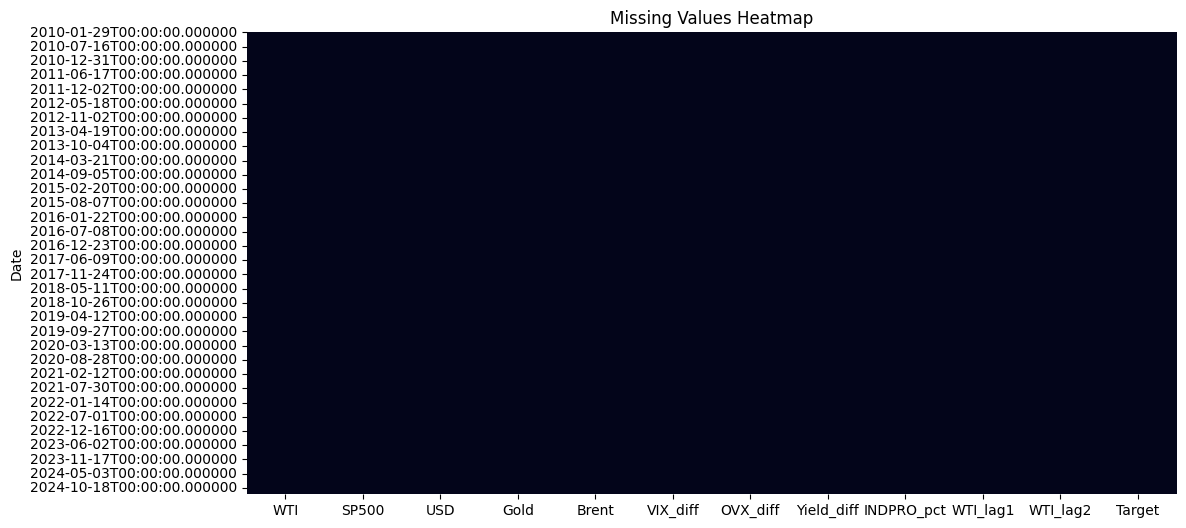

In [632]:


plt.figure(figsize=(12,6))
sns.heatmap(model_data.isna(), cbar=False)

plt.title("Missing Values Heatmap")
plt.show()

After data transformation and pre-processing, no further missing values existed. 
The entire dataset was therefore available for the development of predictive models, with no risk of missing data influencing either the training or evaluation of these models.

In [633]:
#check for duplicate rows
model_data.index.duplicated().sum()

0

In [634]:
model_data.dtypes

WTI           float64
SP500         float64
USD           float64
Gold          float64
Brent         float64
VIX_diff      float64
OVX_diff      float64
Yield_diff    float64
INDPRO_pct    float64
WTI_lag1      float64
WTI_lag2      float64
Target        float64
dtype: object

In [635]:
summary = model_data.describe().T

summary['skew'] = model_data.skew()
summary['kurtosis'] = model_data.kurtosis()

summary

,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
WTI,779.0,-0.000052,0.057729,-0.487559,-0.025124,0.002533,0.026348,0.605431,0.438074,23.178488
SP500,779.0,0.002181,0.022587,-0.162279,-0.008079,0.003653,0.014359,0.114237,-0.789971,6.360198
USD,779.0,0.000415,0.007183,-0.020503,-0.004510,0.000787,0.004604,0.036661,0.386339,1.523635
Gold,779.0,0.001125,0.021376,-0.101316,-0.010098,0.002125,0.013557,0.090090,-0.275456,1.887471
Brent,779.0,0.000018,0.050219,-0.346390,-0.023736,0.002719,0.027627,0.270361,-0.394912,6.172399
VIX_diff,779.0,-0.014583,3.335876,-18.740000,-1.480000,-0.190000,1.265000,23.030000,0.767549,7.729657
OVX_diff,779.0,-0.005956,6.966134,-63.349998,-2.065000,-0.250000,1.695001,77.619995,2.648541,48.823570
Yield_diff,779.0,-0.002529,0.064769,-0.280000,-0.040000,-0.010000,0.030000,0.320000,0.051025,1.827119
INDPRO_pct,779.0,0.000174,0.006510,-0.131878,0.000000,0.000000,0.000000,0.065530,-9.253524,237.353238
WTI_lag1,779.0,-0.000144,0.057750,-0.487559,-0.025228,0.002520,0.026348,0.605431,0.441502,23.144217




* **count**: Number of observations in the dataset. All variables contain 779 data points.

* **mean**: The average value of the variable. Most means are close to zero, suggesting returns and changes fluctuate around a stable average.

* **std (standard deviation)**: Measures volatility or dispersion. Higher values indicate greater variability. For example, `OVX_diff` has high volatility compared to `USD`.

* **min**: The lowest observed value in the dataset.

* **25% (Q1)**: The first quartile. 25% of observations fall below this value.

* **50% (median)**: The middle value of the distribution.

* **75% (Q3)**: The third quartile. 75% of observations fall below this value.

* **max**: The highest observed value.

* **skew**: Measures asymmetry in the distribution.

  * Positive skew → longer right tail.
  * Negative skew → longer left tail.
    For example, `OVX_diff` is highly positively skewed.

* **kurtosis**: Measures the heaviness of tails and presence of extreme values.

  * High kurtosis indicates more extreme observations/outliers.
  * Variables like `INDPRO_pct` and `OVX_diff` show very high kurtosis, suggesting extreme market events or shocks.

> Overall, the descriptive statistics suggest that several financial variables exhibit high volatility, skewness, and kurtosis, indicating non-normal and nonlinear behaviour commonly observed in financial time-series data.


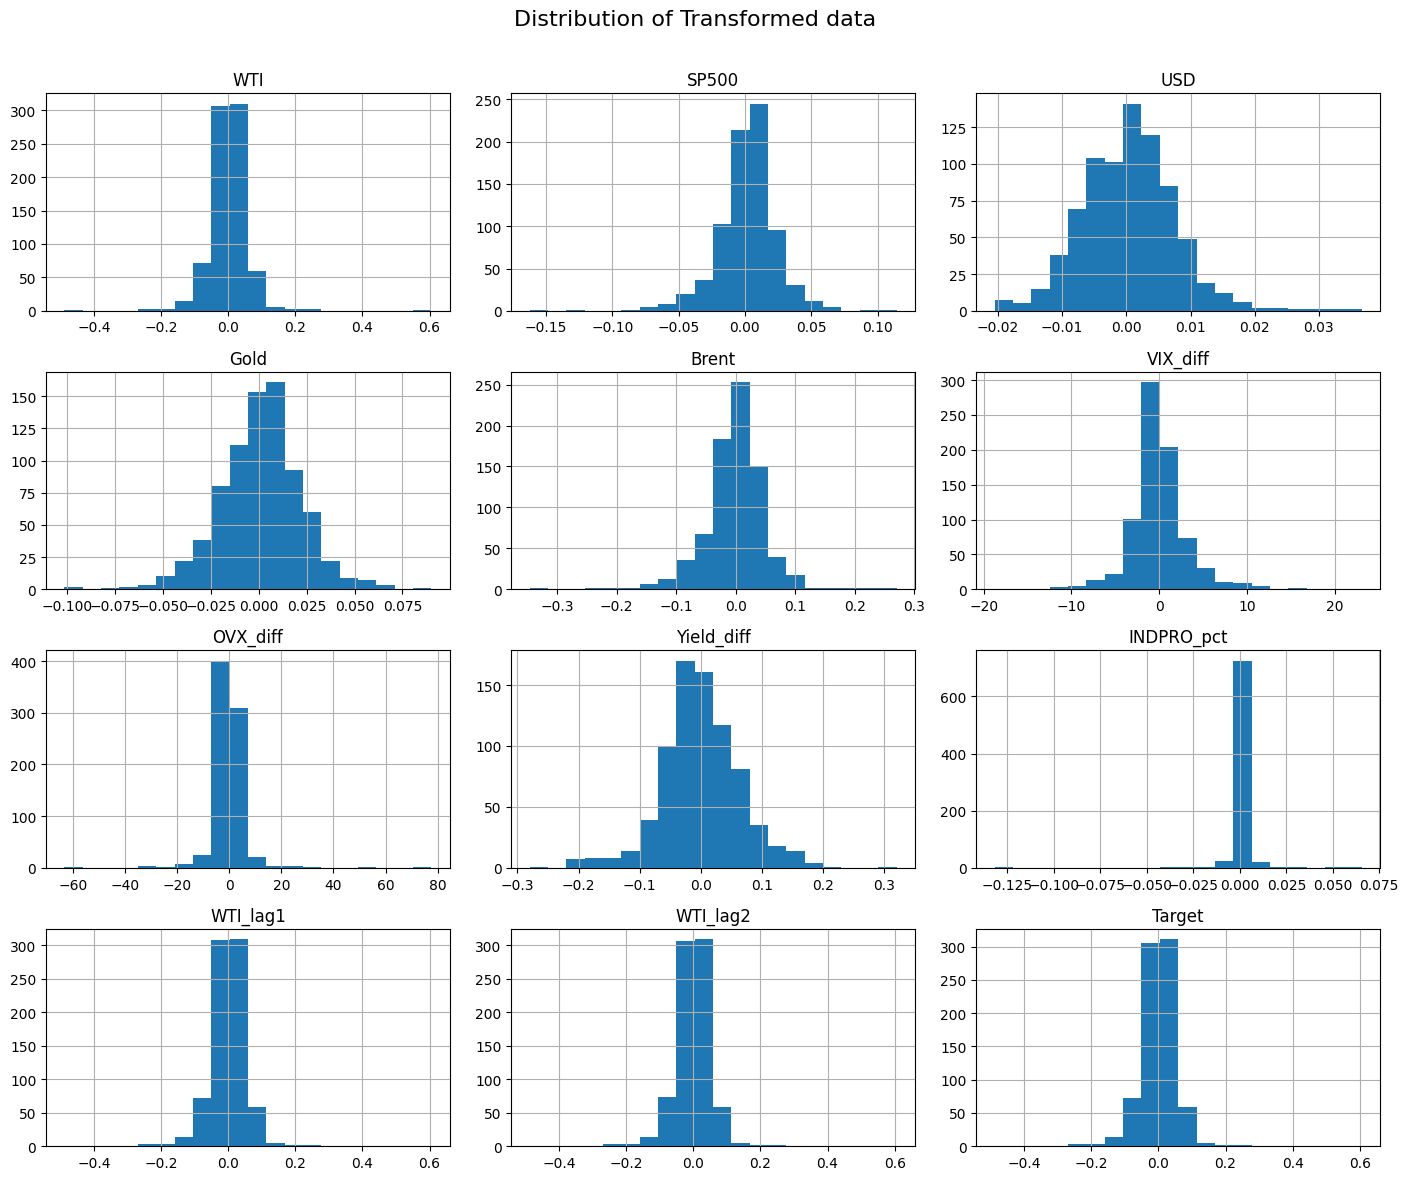

In [636]:
model_data.hist(figsize=(14, 12), bins=20)

plt.suptitle("Distribution of Transformed data", fontsize=16)

plt.tight_layout(rect=[0, 0, 1, 0.97])  
plt.show()

The transformed variables are more centered around zero and display distributions that are closer to normality. Some variables retain heavier tails due to extreme market events, but the transformations significantly reduce skewness and scale differences.

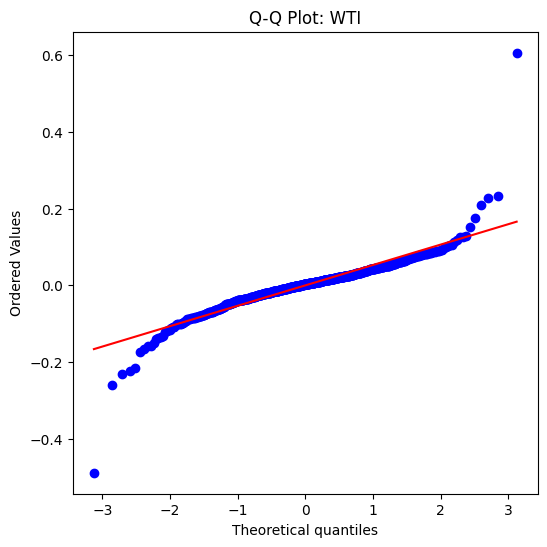

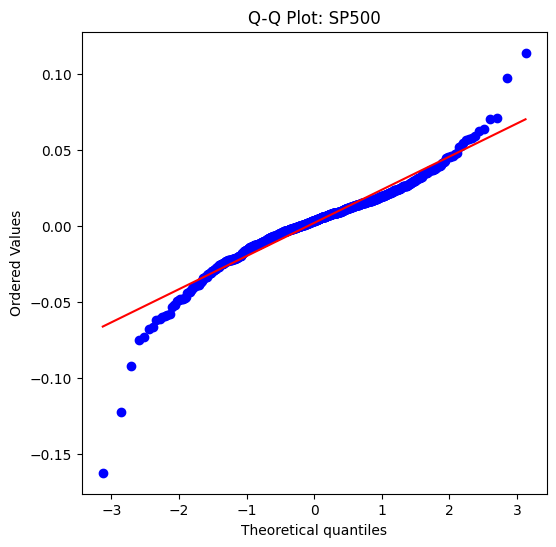

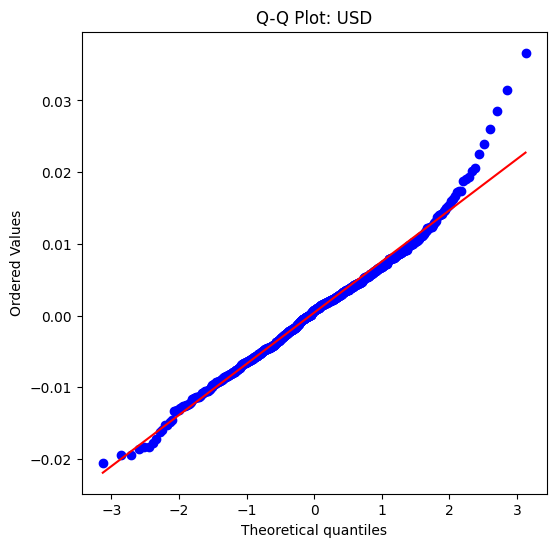

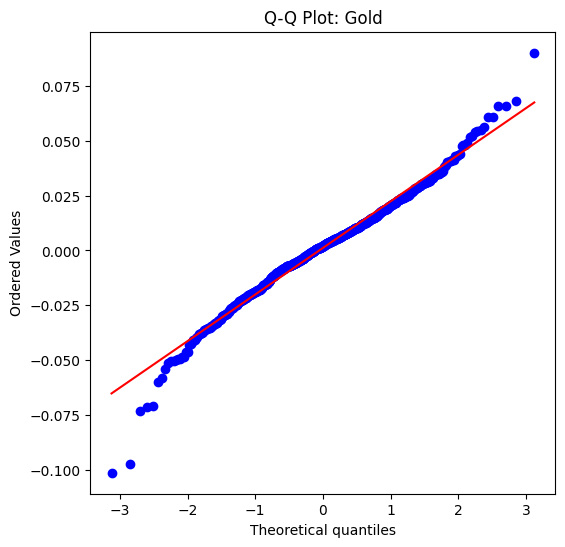

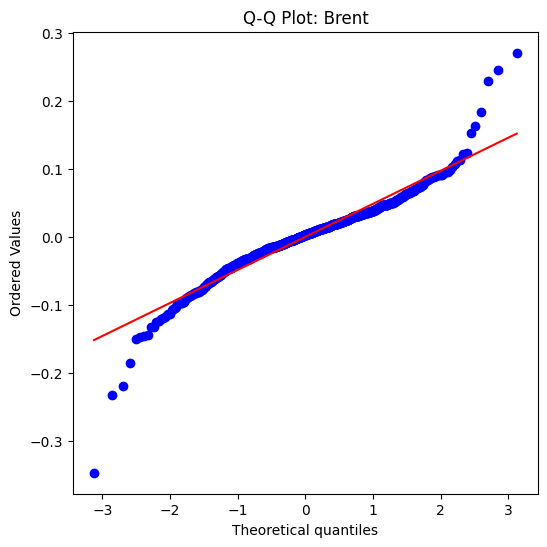

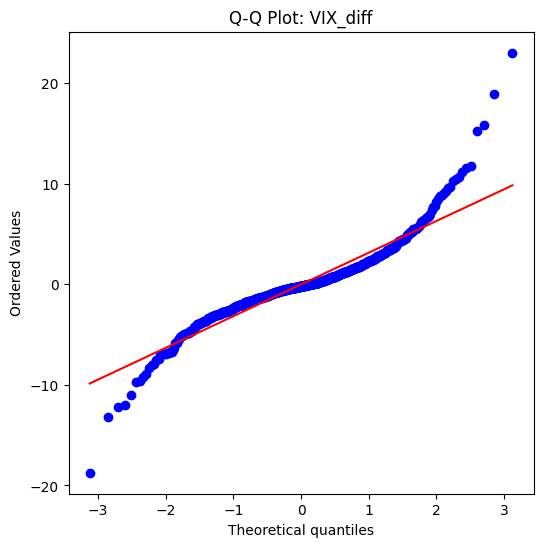

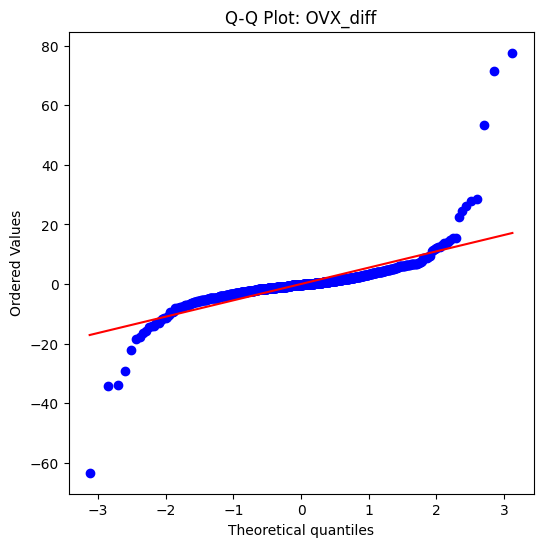

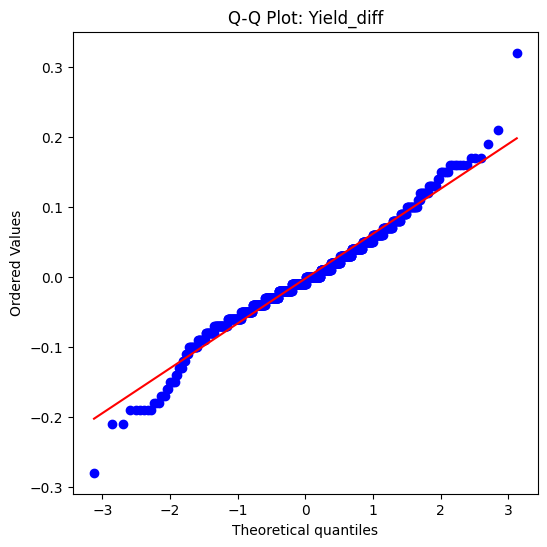

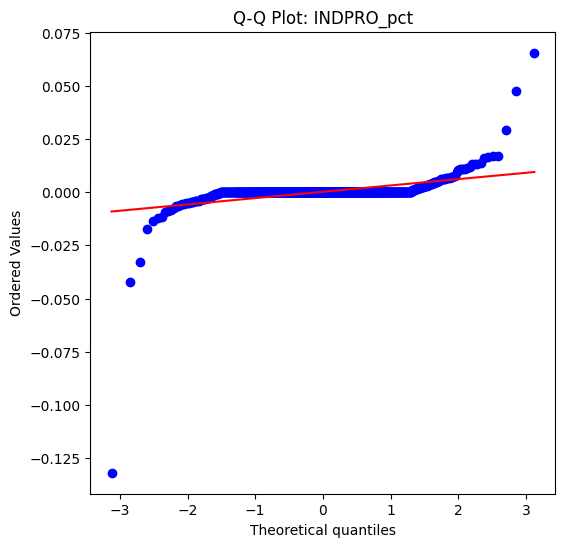

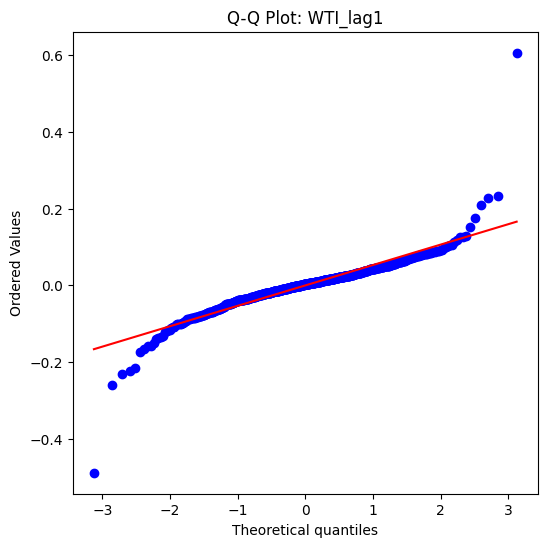

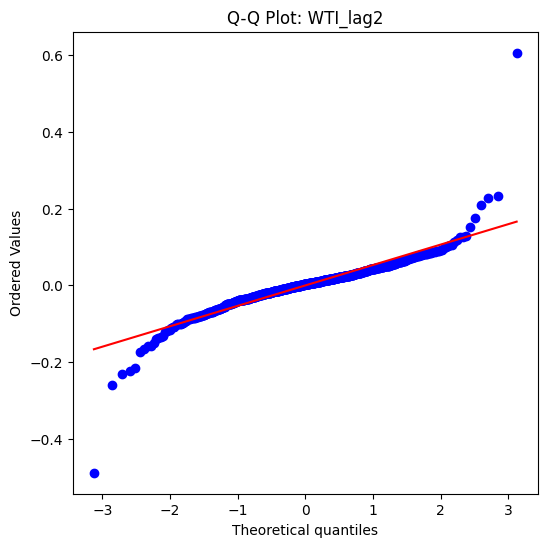

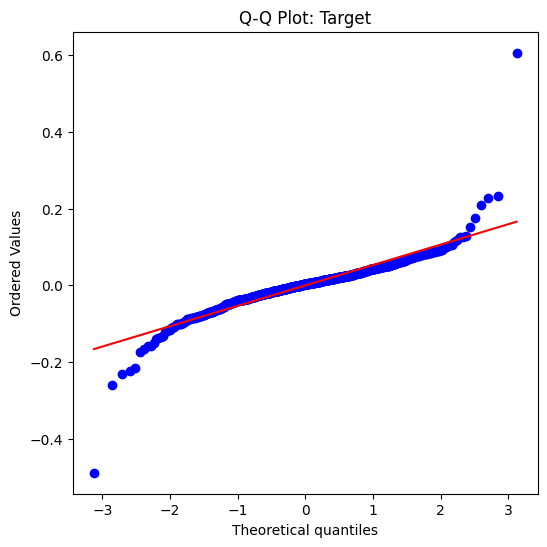

In [637]:
for col in model_data.columns:
    plt.figure(figsize=(6,6))
    
    stats.probplot(model_data[col], dist="norm", plot=plt)
    
    plt.title(f'Q-Q Plot: {col}')
    plt.show()

The Q – Q plots show that most of the distribution of the transformed data is approximately normal with little to no deviations from a straight line (normality) near the center of the distributions. Deviations at the ends suggest some infrequent instances where extreme values occurred during the sample period as well as heavier than normal tailedness present in many financial datasets

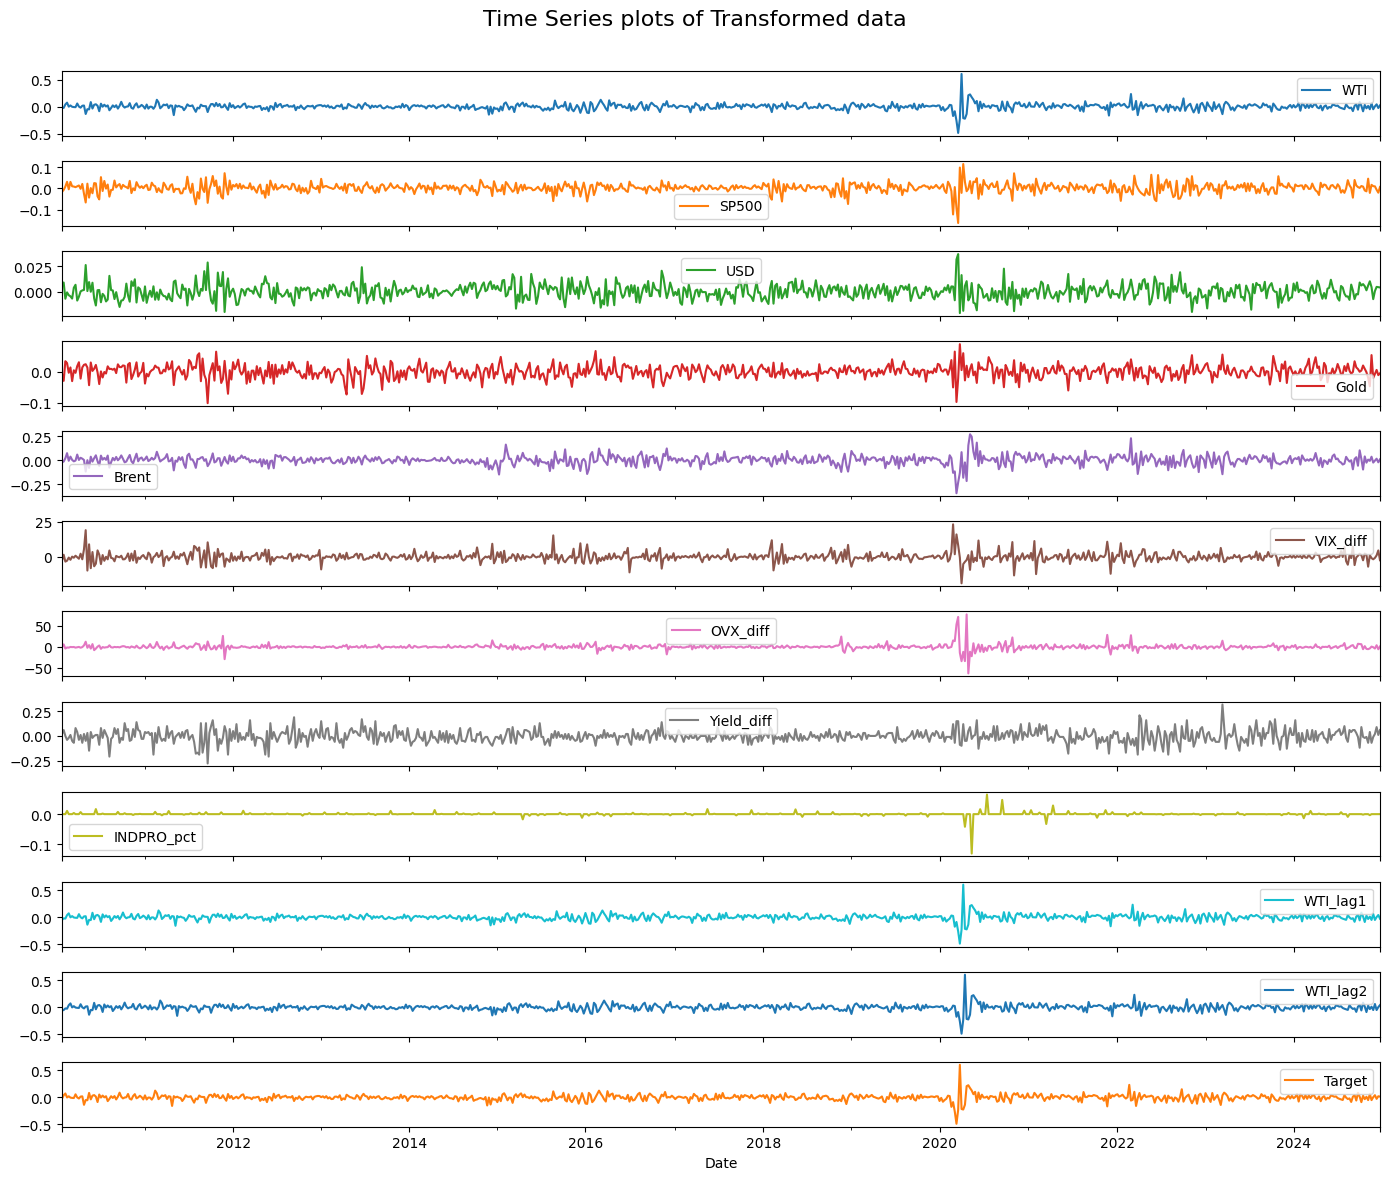

In [638]:
axes = model_data.plot(subplots=True, figsize=(14, 12))

fig = axes[0].get_figure()
fig.suptitle("Time Series plots of Transformed data", fontsize=16)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

After adjusting data (returns, differences and % changes), all of the time series are fluctuating around a nearly constant mean approximately equal to zero. The volatility clustering can still be observed with an increased visibility in the year 2020. Therefore, after removing the trend, we observe that these time series look like they could be modelled using statistical models. In order to confirm this assumption, it is necessary to run ADF tests.

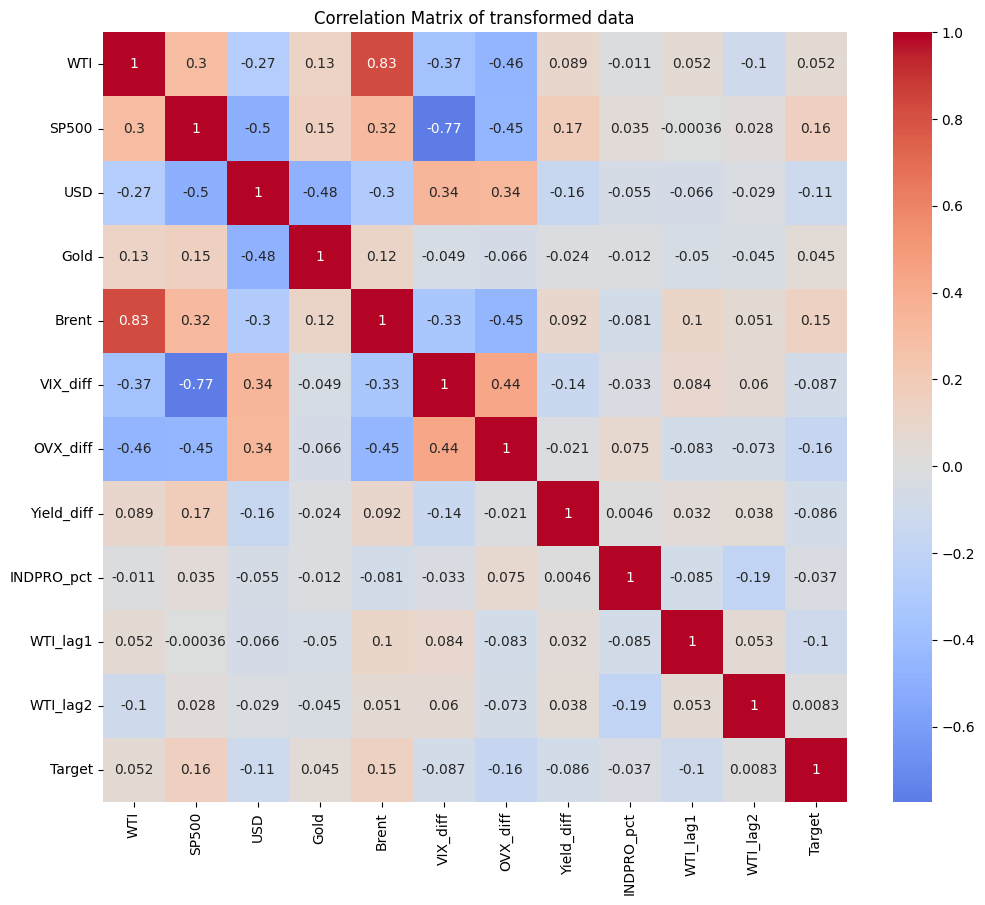

In [639]:
corr = model_data.corr()

plt.figure(figsize=(12,10))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    center=0
)

plt.title('Correlation Matrix of transformed data')
plt.show()

In terms of predictor-target correlations, they were generally small in magnitude as would be expected when attempting to predict financial returns. 
This also supports the need for using machine learning models, as they can identify non-linear patterns within data, and there does appear to be some degree of non-linearity in the relationship between each predictor and the target variable.

In [640]:
corr['Target'].sort_values(ascending=False)

Target        1.000000
SP500         0.156089
Brent         0.147078
WTI           0.051632
Gold          0.044720
WTI_lag2      0.008284
INDPRO_pct   -0.036934
Yield_diff   -0.085742
VIX_diff     -0.087081
WTI_lag1     -0.104829
USD          -0.113661
OVX_diff     -0.163843
Name: Target, dtype: float64

The variables with the strongest relationship with the target variable in descending order is: SP500, WTI, Gold, WTI_lag2, INDPRO_pct, Yield_diff, VIX_diff, WTI_lag1, USD, OVX_diff. 

C:\Users\komet\AppData\Local\Temp\ipykernel_10672\3025616407.py:7: FutureWarning: PeriodDtype[B] is deprecated and will be removed in a future version. Use a DatetimeIndex with freq='B' instead
  data["WTI"].plot(ax=ax2, color="red", label="Raw data")


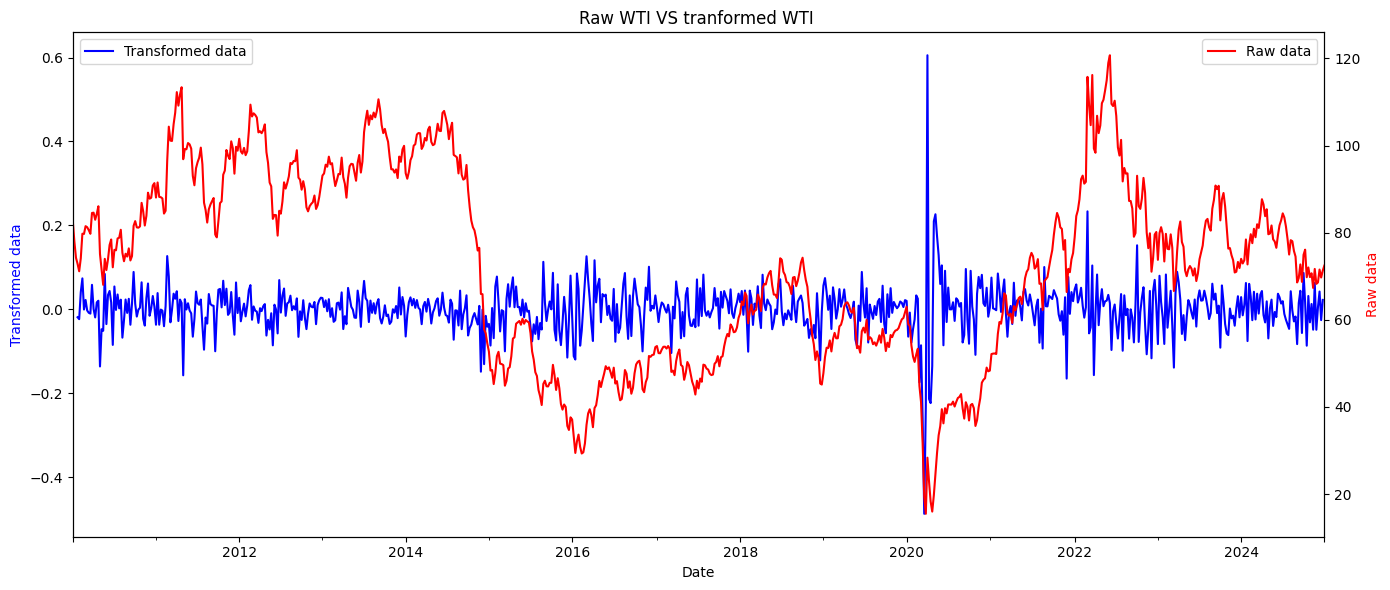

In [641]:
fig, ax1 = plt.subplots(figsize=(14, 6))

model_data["WTI"].plot(ax=ax1, color="blue", label="Transformed data")
ax1.set_ylabel("Transformed data", color="blue")

ax2 = ax1.twinx()
data["WTI"].plot(ax=ax2, color="red", label="Raw data")
ax2.set_ylabel("Raw data", color="red")

ax1.legend(loc="upper left")
ax2.legend(loc="upper right")

plt.title("Raw WTI VS tranformed WTI ")
plt.tight_layout()
plt.show()

There is huge difference between raw data and transformed data, raw data is nonstationary while transformed data is stationary. Thereby justifying the transformation. Both plot have very high volatility in 2020

In [642]:
results = []

for col in model_data.columns:
    result = adfuller(model_data[col].dropna())
    
    results.append({
        'Variable': col,
        'ADF Statistic': round(result[0], 4),
        'p-value': round(result[1], 4),
        'Conclusion': 'Stationary' if result[1] < 0.05 else 'Non-stationary'
    })

# Convert to DataFrame
adf_table = pd.DataFrame(results)
adf_table = adf_table.sort_values(by='p-value')
# Display nicely
adf_table

,Variable,ADF Statistic,p-value,Conclusion
0,WTI,-9.8045,0.0,Stationary
1,SP500,-14.3019,0.0,Stationary
2,USD,-27.3380,0.0,Stationary
3,Gold,-17.4913,0.0,Stationary
4,Brent,-9.9490,0.0,Stationary
5,VIX_diff,-12.0293,0.0,Stationary
6,OVX_diff,-9.1753,0.0,Stationary
7,Yield_diff,-7.6818,0.0,Stationary
8,INDPRO_pct,-8.5517,0.0,Stationary
9,WTI_lag1,-9.7877,0.0,Stationary


Based on ADF tests all transformed variables are stationary. 

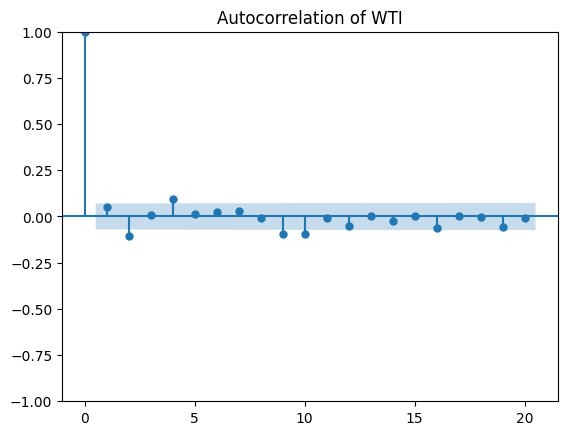

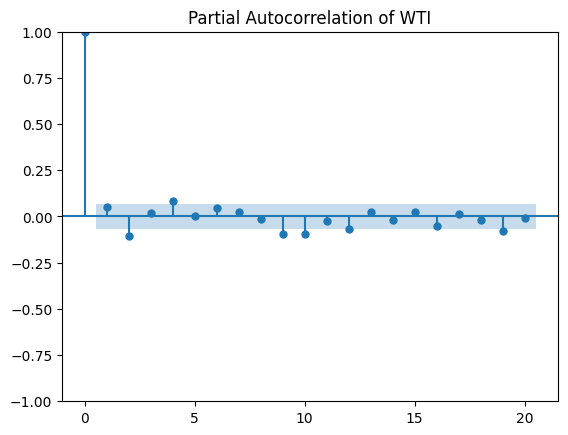

In [643]:

plot_acf(model_data['WTI'], lags=20)
plt.title("Autocorrelation of WTI")
plt.show()

plot_pacf(model_data['WTI'], lags=20)
plt.title("Partial Autocorrelation of WTI")
plt.show()

The ACF and PACF plots indicate that all but one of the autocorrelation coefficients are contained within the 95 percent confidence interval (indicating no statistically significant serial correlation) which supports the conclusion that the transform has greatly reduced the time-series structure in the original WTI price series.

There appears to be a slightly positive, though still statistically insignificant, at lag 2; therefore, there is weak evidence for an association between past and future returns on WTI prices over a relatively short horizon. Although this association is not strong enough to justify inclusion of prior WTI return values into forecast model(s), it does provide some theoretical basis for doing so.

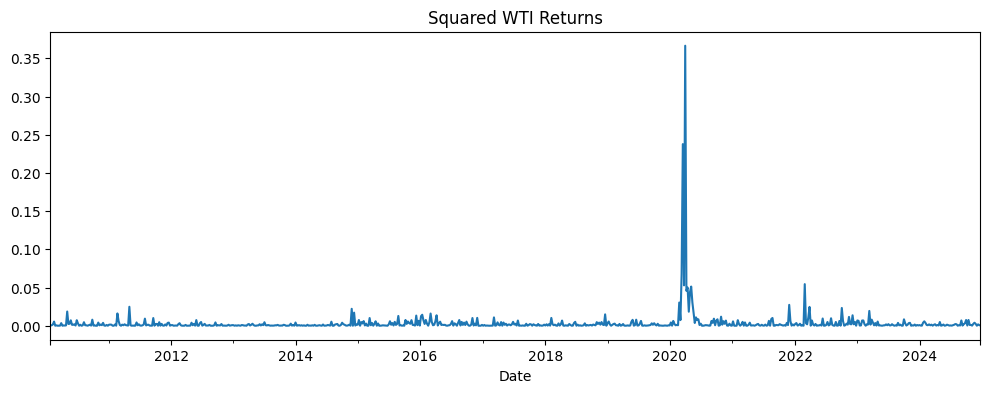

In [644]:
(model_data['WTI']**2).plot(figsize=(12,4))

plt.title('Squared WTI Returns')
plt.show()

The squared WTI returns have been graphed to find how volatility moves over time. It shows that a large amount of volatility is clustered together. That is to say, when there was a lot of price movement in one period, then it will also be very volatile during the next few periods. In other words, this is a common property of many financial time series and demonstrates that we need to allow for heteroskedasticity. Therefore these graphs justify our decision to include both volatility related factors (VIX and OVX) and to model things non-linearly.

In [645]:
X = model_data.drop(columns=['Target'])

vif = pd.DataFrame()
vif['Feature'] = X.columns

vif['VIF'] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

vif

,Feature,VIF
0,WTI,3.662471
1,SP500,3.031349
2,USD,1.818097
3,Gold,1.375534
4,Brent,3.521312
5,VIX_diff,2.799954
6,OVX_diff,1.575246
7,Yield_diff,1.064332
8,INDPRO_pct,1.069411
9,WTI_lag1,1.061252


An examination for Multicollinearity was performed using Variance Inflation Factors (VIF). All predictor variables had a VIF less than five which indicated that there are minimal correlations between each set of features. These results suggest that there is no Multicollinearity within this data; therefore, all of the variables that have been selected provide new information to the model. Based upon the relatively small VIFs it can be inferred that the feature transformation and/or the selection of features has minimized redundant predictive relationships.

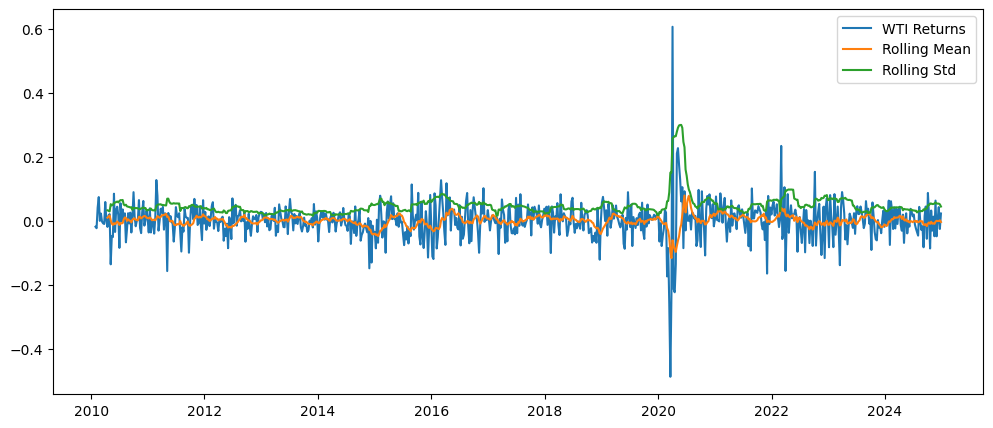

In [646]:
rolling_mean = model_data['WTI'].rolling(12).mean()
rolling_std = model_data['WTI'].rolling(12).std()

plt.figure(figsize=(12,5))

plt.plot(model_data['WTI'], label='WTI Returns')
plt.plot(rolling_mean, label='Rolling Mean')
plt.plot(rolling_std, label='Rolling Std')

plt.legend()
plt.show()

The mean is very consistent for most of the sampling period (the mean doesn't deviate much from zero). This implies that the WTI returns after transformation tend to oscillate about a constant average. The standard deviation tends to vary through time; it was substantially higher than normal for some time in 2020 due to the extraordinary price volatility brought on by the COVID-19 pandemic and a short-term decline in oil prices. In general, this data set has appeared to be relatively stationary in terms of the mean, while clusters of high volatility have been seen as they often are within financial time series.

In [647]:
model_data['OVX_diff'].corr(model_data['Target'])

-0.1638432417270139

In [648]:
for lag in range(1, 6):
    corr = model_data['OVX_diff'].shift(lag).corr(model_data['Target'])
    
    print(f'Lag {lag}: {corr}')

Lag 1: 0.10645111378550663
Lag 2: 0.035165545739884334
Lag 3: -0.11668587842452492
Lag 4: -0.13126684800251395
Lag 5: 0.01225838788516485


A lagged correlation test was performed to find a connection in time between oil price volatility (OVX), and future prices of West Texas Intermediate (WTI) crude. It was found that there are very weak positive correlations of the relationship over all lag periods. The strongest relationship is at one month lag period (.106). The fact that the relationship changes signs on each lag, indicates both an interaction between variables and possibly non-linear relationships. Therefore, although OVX does not appear to have high predictive power in terms of its ability to be related to the forecasted values of WTI using linear methods; it can likely contribute positively to forecasting results if incorporated into nonlinear Machine Learning modeling techniques.

These low levels of lagged correlations also reinforce previous findings from the correlation matrices, supporting the use of non-linear modeling approaches such as tree based methodologies.

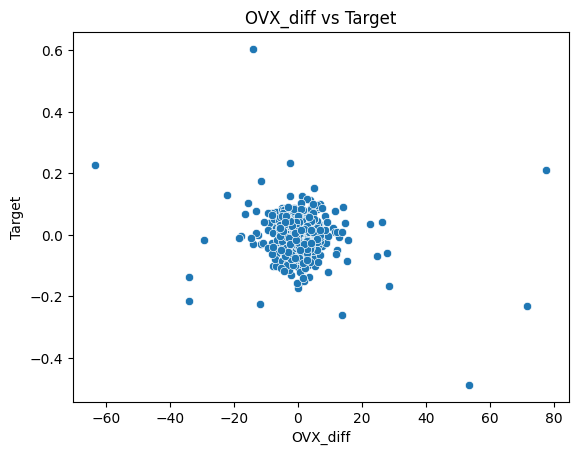

In [649]:
sns.scatterplot(
    x=model_data['OVX_diff'],
    y=model_data['Target']
)
plt.title("OVX_diff vs Target")
plt.show()

There is no visible pattern between OVX_diff and Target. The presence of no visble pattern justifies the use of Machine learning for modelling.

In [650]:
#get periods of high vix and periods of low vix.
high_vix = model_data[model_data['VIX_diff'] > 0]
low_vix = model_data[model_data['VIX_diff'] <= 0]

In [651]:
high_vix['WTI'].mean()

-0.010889396031491359

In [652]:
low_vix['WTI'].mean()

0.008697651564823055

In [653]:
high_vix['WTI'].std()

0.05861289703911135

In [654]:
low_vix['WTI'].std()

0.05554795411270954

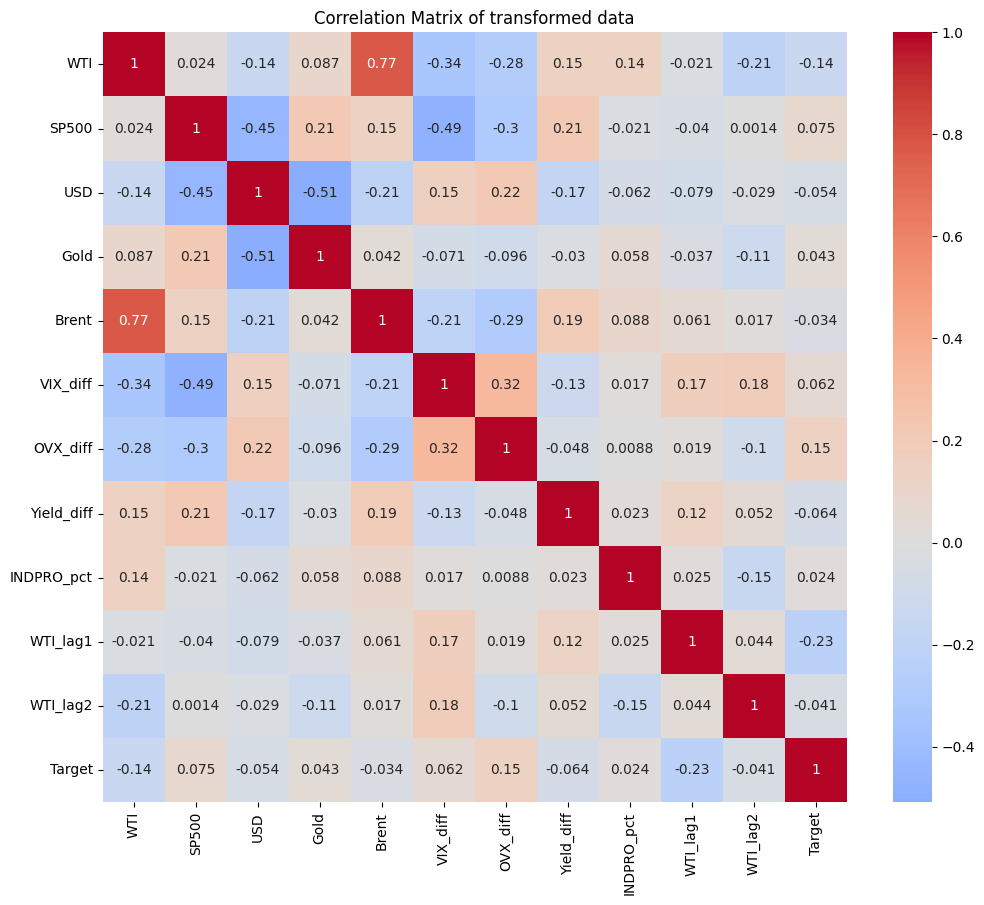

In [655]:

corr=low_vix.corr()

plt.figure(figsize=(12,10))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    center=0
)

plt.title('Correlation Matrix of transformed data')
plt.show()

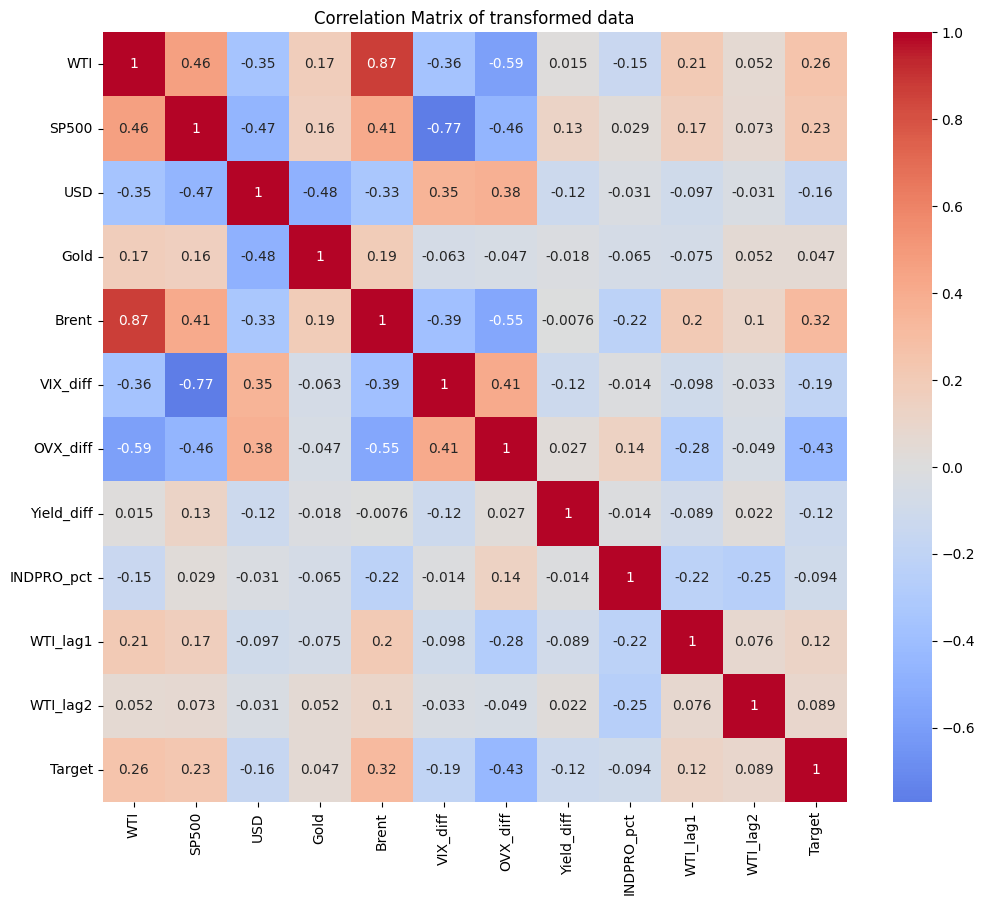

In [656]:
corr = high_vix.corr()

plt.figure(figsize=(12,10))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    center=0
)

plt.title('Correlation Matrix of transformed data')
plt.show()

To evaluate whether crude oil price dynamics respond to changes in markets, we used a partitioning approach (e.g., dividing our data into two regimes) to identify "high" and "low" volatility regimes based on historical changes in the VIX index. We found that correlations between our explanatory variables and future WTI returns are typically quite small or not different from zero during times of little stress (i.e., calm), while they are clearly much larger during periods of heightened stress. Specifically, OVX, S&P500 and VIX demonstrate significantly higher correlations to future oil prices than do other variable combinations when the volatility regime shifts to be higher. Overall, this supports the idea that how oil behaves is dependent upon which regime it is experiencing, as well as the suitability of using machine learning techniques to model those complex interactions.

In [657]:
#split the data, use 80% for training and 20% for testing 
split = int(len(model_data)*0.8)

train = model_data.iloc[:split]
test = model_data.iloc[split:]

In [658]:
for lag in range(1, 9):
    model_data[f'WTI_lag{lag}'] = model_data['WTI'].shift(lag)

In [659]:
model_data['WTI_roll4'] = model_data['WTI'].rolling(4).mean()

In [660]:
model_data['WTI_vol4'] = model_data['WTI'].rolling(4).std()

In [661]:
model_data = model_data.dropna()

In [662]:
model_data

,WTI,SP500,USD,Gold,Brent,VIX_diff,OVX_diff,Yield_diff,INDPRO_pct,WTI_lag1,WTI_lag2,Target,WTI_lag3,WTI_lag4,WTI_lag5,WTI_lag6,WTI_lag7,WTI_lag8,WTI_roll4,WTI_vol4
Date,,,,,,,,,,,,,,,,,,,,
2010-03-26,-0.010354,0.005751,0.006926,-0.002894,-0.004989,0.80,-1.750000,0.08,0.000000,-0.008403,-0.002949,0.058210,0.022083,-0.000627,0.073597,0.040760,-0.023612,-0.019035,0.000094,0.014990
2010-04-02,0.058210,0.009818,-0.008378,0.018751,0.057920,-0.30,-0.860001,0.04,0.000000,-0.010354,-0.008403,0.000828,-0.002949,0.022083,-0.000627,0.073597,0.040760,-0.023612,0.009126,0.032872
2010-04-09,0.000828,0.013716,-0.004623,0.031496,0.001693,-1.33,-0.090000,-0.04,0.000000,0.058210,-0.010354,-0.019455,-0.008403,-0.002949,0.022083,-0.000627,0.073597,0.040760,0.010070,0.032462
2010-04-16,-0.019455,-0.001877,0.000520,-0.021590,0.024348,2.22,-1.990000,0.01,0.006857,0.000828,0.058210,0.016377,-0.010354,-0.008403,-0.002949,0.022083,-0.000627,0.073597,0.007307,0.034934
2010-04-23,0.016377,0.020877,0.001479,0.014677,0.014980,-1.74,-0.480000,-0.07,0.000000,-0.019455,0.000828,0.020305,0.058210,-0.010354,-0.008403,-0.002949,0.022083,-0.000627,0.013990,0.032929
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-11-29,-0.048888,0.010505,-0.007018,-0.019714,-0.025823,-1.73,-0.790001,-0.01,0.000000,0.062606,-0.048698,0.004677,0.012527,-0.031167,0.031596,-0.086832,0.015625,0.086514,-0.005613,0.053889
2024-12-06,0.004677,0.009551,0.000854,-0.006949,-0.005137,-0.74,-3.970001,0.02,0.000000,-0.048888,0.062606,0.042256,-0.048698,0.012527,-0.031167,0.031596,-0.086832,0.015625,-0.007576,0.053146
2024-12-13,0.042256,-0.006454,0.004895,0.006573,0.014933,1.04,3.939999,0.09,0.000000,0.004677,-0.048888,-0.025913,0.062606,-0.048698,0.012527,-0.031167,0.031596,-0.086832,0.015163,0.048981


In [663]:
model_data.isna().sum()

WTI           0
SP500         0
USD           0
Gold          0
Brent         0
VIX_diff      0
OVX_diff      0
Yield_diff    0
INDPRO_pct    0
WTI_lag1      0
WTI_lag2      0
Target        0
WTI_lag3      0
WTI_lag4      0
WTI_lag5      0
WTI_lag6      0
WTI_lag7      0
WTI_lag8      0
WTI_roll4     0
WTI_vol4      0
dtype: int64

In [664]:
high_vix = model_data[model_data['VIX_diff'] > 0]
low_vix = model_data[model_data['VIX_diff'] <= 0]

In [687]:
#split the data, use 80% for training and 20% for testing 
split = int(len(model_data)*0.8)

train = model_data.iloc[:split]
test = model_data.iloc[split:]

In [688]:
from sklearn.linear_model import LogisticRegression 
from sklearn.model_selection import train_test_split 
from sklearn.metrics import accuracy_score, confusion_matrix 
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from skopt import BayesSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler

In [689]:
import os

os.environ["PYTHONHASHSEED"] = "42"
os.environ["TF_DETERMINISTIC_OPS"] = "1"

import random
import numpy as np
import tensorflow as tf

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

In [690]:

# -------------------------
# 1. Define X and y
# -------------------------
X_train = train.drop(columns=['Target'])
y_train = train['Target']

X_test = test.drop(columns=['Target'])
y_test = test['Target']

In [691]:
baseline_pred = np.repeat(y_train.mean(), len(y_test))

print("Baseline RMSE:", np.sqrt(mean_squared_error(y_test, baseline_pred)))
print("Baseline MAE:", mean_absolute_error(y_test, baseline_pred))
print("Baseline R2:", r2_score(y_test, baseline_pred))
print("Baseline Directional Accuracy:", np.mean(np.sign(baseline_pred) == np.sign(y_test)))

Baseline RMSE: 0.05217548447527434
Baseline MAE: 0.03947847115373623
Baseline R2: -0.00038396046916844284
Baseline Directional Accuracy: 0.5290322580645161


In [692]:

# -------------------------
# 2. Evaluation function
# -------------------------
def evaluate_model(model_name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    directional_accuracy = np.mean(np.sign(y_true) == np.sign(y_pred))

    return {
        'Model': model_name,
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2,
        'Directional Accuracy': directional_accuracy
    }


# -------------------------
# 3. Linear Regression
# -------------------------
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)




In [693]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit
from skopt import BayesSearchCV

tscv = TimeSeriesSplit(n_splits=3)

search_spaces = {
    'n_estimators': (100, 500),
    'max_depth': (3, 15),
    'min_samples_split': (2, 20),
    'min_samples_leaf': (1, 10),
    'max_features': ['sqrt', 'log2']
}

rf_model = RandomForestRegressor(
    random_state=42,
    oob_score=True,
    bootstrap=True
)

bayes_search = BayesSearchCV(
    rf_model,
    search_spaces,
    n_iter=30,
    cv=tscv,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    random_state=42
)

bayes_search.fit(X_train, y_train)

BayesSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=3, test_size=None),
              estimator=RandomForestRegressor(oob_score=True, random_state=42),
              n_iter=30, n_jobs=-1, random_state=42,
              scoring='neg_mean_absolute_error',
              search_spaces={'max_depth': (3, 15),
                             'max_features': ['sqrt', 'log2'],
                             'min_samples_leaf': (1, 10),
                             'min_samples_split': (2, 20),
                             'n_estimators': (100, 500)})

In [694]:
# -------------------------
# 4. Random Forest
# -------------------------
# Train model
rfg = RandomForestRegressor(**bayes_search.best_params_)
rfg.fit(X_train, y_train)
rfg.criterion
# Predict
y_train_pred = rfg.predict(X_train)
y_test_pred = rfg.predict(X_test)

print("Random Forest Regressor TRAIN PERFORMANCE ")
print("R2:", r2_score(y_train, y_train_pred))
print("MAE:", mean_absolute_error(y_train, y_train_pred))
print("RMSE:", mean_squared_error(y_train, y_train_pred, squared=False))

# Evaluate
print("Random Forest Regressor Test Performance:")
print("RMSE:", mean_squared_error(y_test, y_test_pred, squared=False))
print("R2 Score:", r2_score(y_test, y_test_pred))
print("MAE:", mean_absolute_error(y_test, y_test_pred))

# Directional Accuracy
direction_acc = np.mean(
    np.sign(y_test_pred) == np.sign(y_test)
)

print("Directional Accuracy:", direction_acc)



Random Forest Regressor TRAIN PERFORMANCE 
R2: 0.27670872565802906
MAE: 0.030071262543892276
RMSE: 0.0503891970765685
Random Forest Regressor Test Performance:
RMSE: 0.053334391542425544
R2 Score: -0.045318000003357284
MAE: 0.04091006579282896
Directional Accuracy: 0.41935483870967744


c:\Users\komet\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\komet\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [695]:
# -------------------------
# 5. Compare results
# -------------------------
results = pd.DataFrame([
    evaluate_model('Linear Regression', y_test, lr_pred),
    evaluate_model('Random Forest', y_test, y_test_pred)
])

results

,Model,RMSE,MAE,R2,Directional Accuracy
0,Linear Regression,0.057460,0.043801,-0.213285,0.516129
1,Random Forest,0.053334,0.040910,-0.045318,0.419355


In [696]:
from xgboost import XGBRegressor
from sklearn.model_selection import TimeSeriesSplit
from skopt import BayesSearchCV

# Time-series cross validation
tscv = TimeSeriesSplit(n_splits=3)

# XGBoost search space
search_spaces = {
    'n_estimators': (100, 500),
    'max_depth': (2, 10),
    'learning_rate': (0.01, 0.3, 'log-uniform'),
    'subsample': (0.5, 1.0),
    'colsample_bytree': (0.5, 1.0),
    'min_child_weight': (1, 10)
}

xgb = XGBRegressor(
    objective='reg:squarederror',
    random_state=42
)

bayes_search = BayesSearchCV(
    xgb,
    search_spaces,
    n_iter=30,
    cv=tscv,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    random_state=42
)

bayes_search.fit(X_train, y_train)

print("Best Parameters:")
print(bayes_search.best_params_)

Best Parameters:
OrderedDict([('colsample_bytree', 0.5), ('learning_rate', 0.01), ('max_depth', 2), ('min_child_weight', 1), ('n_estimators', 100), ('subsample', 0.5127575386511484)])


In [697]:
xgb_best = XGBRegressor(
    **bayes_search.best_params_,
    objective='reg:squarederror',
    random_state=42
)

xgb_best.fit(X_train, y_train)

y_train_pred = xgb_best.predict(X_train)
y_test_pred = xgb_best.predict(X_test)

In [698]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

print("XGBoost TRAIN")
print("R2:", r2_score(y_train, y_train_pred))
print("MAE:", mean_absolute_error(y_train, y_train_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_train, y_train_pred)))

print("\nXGBoost TEST")
print("R2:", r2_score(y_test, y_test_pred))
print("MAE:", mean_absolute_error(y_test, y_test_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_test_pred)))

# Directional Accuracy
direction_acc = np.mean(
    np.sign(y_test_pred) == np.sign(y_test)
)

print("Directional Accuracy:", direction_acc)

XGBoost TRAIN
R2: 0.14639127135620822
MAE: 0.03597435754944444
RMSE: 0.054740687677112196

XGBoost TEST
R2: -0.014155637393818532
MAE: 0.039767228834938155
RMSE: 0.05253339097987093
Directional Accuracy: 0.5032258064516129


In [ ]:
import os
import random
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import backend as K


# -------------------------
# Scale data
# -------------------------
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)




# -------------------------
# Improved LSTM shape: sequence input
# -------------------------
def create_sequences(X, y, time_steps=8):
    Xs, ys = [], []

    y_values = y.values if hasattr(y, "values") else y

    for i in range(time_steps, len(X)):
        Xs.append(X[i-time_steps:i])
        ys.append(y_values[i])

    return np.array(Xs), np.array(ys)


time_steps = 8

X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train, time_steps)
X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test, time_steps)


# -------------------------
# Evaluation function
# -------------------------
def evaluate_lstm(y_true, y_pred):
    return {
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE": mean_absolute_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred),
        "Directional Accuracy": np.mean(np.sign(y_pred) == np.sign(y_true))
    }




# -------------------------
# Improved sequence LSTM function
# -------------------------
def run_sequence_lstm(seed):
    K.clear_session()

    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

    model = Sequential()

    model.add(
        LSTM(
            units=64,
            return_sequences=True,
            input_shape=(X_train_seq.shape[1], X_train_seq.shape[2])
        )
    )

    model.add(Dropout(0.3))

    model.add(
        LSTM(
            units=32,
            return_sequences=False
        )
    )

    model.add(Dropout(0.2))
    model.add(Dense(16, activation="relu"))
    model.add(Dense(1))

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="mse"
    )

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=15,
        restore_best_weights=True
    )

    val_split = int(len(X_train_seq) * 0.8)

    model.fit(
        X_train_seq[:val_split],
        y_train_seq[:val_split],
        validation_data=(X_train_seq[val_split:], y_train_seq[val_split:]),
        epochs=100,
        batch_size=32,
        callbacks=[early_stop],
        shuffle=False,
        verbose=0
    )

    y_pred = model.predict(X_test_seq, verbose=0).flatten()

    metrics = evaluate_lstm(y_test_seq, y_pred)
    metrics["Model"] = "Sequence LSTM"
    metrics["Seed"] = seed

    return metrics


# -------------------------
# Run both models over multiple seeds
# -------------------------
seeds = [42, 123, 999, 2025, 2026]

all_results = []

for seed in seeds:
    all_results.append(run_sequence_lstm(seed))

results_df = pd.DataFrame(all_results)


# -------------------------
# Final summary table only
# -------------------------
summary_table = (
    results_df
    .groupby("Model")[["RMSE", "MAE", "R2", "Directional Accuracy"]]
    .agg(["mean", "std"])
    .round(4)
)

summary_table

RMSE             MAE             R2          \
                 mean     std    mean    std    mean     std   
Model                                                          
Sequence LSTM  0.0515  0.0017  0.0406  0.002 -0.0894  0.0728   

              Directional Accuracy          
                              mean     std  
Model                                       
Sequence LSTM               0.4993  0.0321

In [709]:
from prophet import Prophet
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Prepare Prophet data
prophet_train = train.reset_index()[['Date', 'Target']]
prophet_train.columns = ['ds', 'y']

prophet_test = test.reset_index()[['Date', 'Target']]
prophet_test.columns = ['ds', 'y']

# Model
prophet_model = Prophet(
    weekly_seasonality=False,
    yearly_seasonality=True,
    daily_seasonality=False
)

prophet_model.fit(prophet_train)

# Predict
future = prophet_test[['ds']]
forecast = prophet_model.predict(future)

prophet_pred = forecast['yhat'].values

# Evaluation
print("PROPHET TEST")
print("R2:", r2_score(prophet_test['y'], prophet_pred))
print("MAE:", mean_absolute_error(prophet_test['y'], prophet_pred))
print("RMSE:", np.sqrt(mean_squared_error(prophet_test['y'], prophet_pred)))
print("Directional Accuracy:", np.mean(np.sign(prophet_pred) == np.sign(prophet_test['y'])))

16:27:15 - cmdstanpy - INFO - Chain [1] start processing
16:27:15 - cmdstanpy - INFO - Chain [1] done processing


PROPHET TEST
R2: 0.0038144629986319734
MAE: 0.03869039294937139
RMSE: 0.052065884010045235
Directional Accuracy: 0.5483870967741935
